<a href="https://colab.research.google.com/github/Jinan-Bark/H-Copilot/blob/master/notebooks/Prediction_Model_MessyExploration%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load both files
triage = pd.read_csv('ED_triage.csv')
admission = pd.read_csv('ED_admission.csv')

# Join on triage_code
df = pd.merge(triage, admission, on='triage_code', how='inner')

print('Shape:', df.shape)
print('\nYear distribution:')
print(df['ResidentDate_year'].value_counts().sort_index())
print('\nTriageGrade distribution:')
print(df['TriageGrade'].value_counts().sort_index())
print('\nHour distribution:')
print(df['ResidentDate_hour'].value_counts().sort_index())
print('\nNull values in key columns:')
print(df[['ResidentDate_year','ResidentDate_month','ResidentDate_day',
          'ResidentDate_hour','TriageGrade','ChiefComplaint']].isnull().sum())

Shape: (143516, 53)

Year distribution:
ResidentDate_year
2017    25617
2018    29143
2019    32604
2020    24333
2021    25905
2022     5914
Name: count, dtype: int64

TriageGrade distribution:
TriageGrade
1    10312
2    81074
3    34365
4    17746
5       19
Name: count, dtype: int64

Hour distribution:
ResidentDate_hour
0     7001
1     5837
2     4483
3     4137
4     2776
5     2163
6     1826
7     2375
8     3237
9     4326
10    5552
11    6686
12    7039
13    6305
14    6626
15    6809
16    7332
17    7859
18    7611
19    9265
20    8317
21    8603
22    8861
23    8490
Name: count, dtype: int64

Null values in key columns:
ResidentDate_year     0
ResidentDate_month    0
ResidentDate_day      0
ResidentDate_hour     0
TriageGrade           0
ChiefComplaint        0
dtype: int64


In [ ]:
# Find duplicate triage codes
dupes = df[df.duplicated(subset='triage_code', keep=False)]
print('Duplicate triage_code rows:', len(dupes))
print('\nSample duplicates:')
print(dupes[['triage_code', 'ResidentDate_year', 'ResidentDate_month',
             'ResidentDate_day', 'ResidentDate_hour', 'TriageGrade',
             'ChiefComplaint']].head(10).to_string())

Duplicate triage_code rows: 540

Sample duplicates:
       triage_code  ResidentDate_year  ResidentDate_month  ResidentDate_day  ResidentDate_hour  TriageGrade ChiefComplaint
24671  13960927030               2017                  12                18                 12            3         S09.93
24672  13960927030               2017                  12                19                  7            3         S09.93
29335  13961202028               2018                   2                21                 11            2          K92.2
29336  13961202028               2018                   2                21                 14            2          K92.2
30209  13961214003               2018                   3                 5                  0            2            B01
30210  13961214003               2018                   3                 6                 15            2            B01
34233  13970205003               2018                   4                25            

In [ ]:
# Check all duplicates in detail
dupes = df[df.duplicated(subset='triage_code', keep=False)]

# Check if any have different chief complaints or triage grades
different_complaint = dupes.groupby('triage_code')['ChiefComplaint'].nunique()
different_grade = dupes.groupby('triage_code')['TriageGrade'].nunique()

print('Duplicates with different chief complaint:', (different_complaint > 1).sum())
print('Duplicates with different triage grade:', (different_grade > 1).sum())

# Check time difference between duplicate visits
dupes_sorted = dupes.sort_values(['triage_code', 'ResidentDate_year',
                                   'ResidentDate_month', 'ResidentDate_day',
                                   'ResidentDate_hour'])

print('\nTime difference between duplicate records:')
for code, group in dupes_sorted.groupby('triage_code'):
    if len(group) == 2:
        day_diff = group['ResidentDate_day'].max() - group['ResidentDate_day'].min()
        hour_diff = group['ResidentDate_hour'].max() - group['ResidentDate_hour'].min()
        print(f'Code {code}: day diff={day_diff}, hour diff={hour_diff}, complaints={group["ChiefComplaint"].tolist()}')

Duplicates with different chief complaint: 0
Duplicates with different triage grade: 0

Time difference between duplicate records:
Code 13960927030: day diff=1, hour diff=5, complaints=['S09.93', 'S09.93']
Code 13961202028: day diff=0, hour diff=3, complaints=['K92.2', 'K92.2']
Code 13961214003: day diff=1, hour diff=15, complaints=['B01', 'B01']
Code 13970205003: day diff=0, hour diff=14, complaints=['R07.9', 'R07.9']
Code 13970205006: day diff=0, hour diff=12, complaints=['N19', 'N19']
Code 13970205007: day diff=0, hour diff=13, complaints=['R07.9', 'R07.9']
Code 13970205008: day diff=0, hour diff=12, complaints=['R06.00', 'R06.00']
Code 13970205009: day diff=0, hour diff=12, complaints=['R53', 'R53']
Code 13970205010: day diff=0, hour diff=12, complaints=['R42', 'R42']
Code 13970205013: day diff=0, hour diff=13, complaints=['R10.84', 'R10.84']
Code 13970205014: day diff=0, hour diff=8, complaints=['T07', 'T07']
Code 13970205015: day diff=0, hour diff=7, complaints=['R26', 'R26']
Cod

In [ ]:
# Sort by arrival time and keep first record per patient visit
df = df.sort_values(['ResidentDate_year', 'ResidentDate_month',
                     'ResidentDate_day', 'ResidentDate_hour'])
df = df.drop_duplicates(subset='triage_code', keep='first')

print('Final clean dataset:', len(df))
print('Ready for EDA and modeling')

Final clean dataset: 143224
Ready for EDA and modeling


In [ ]:
# Use triage file only - all ED visits
triage = pd.read_csv('ED_triage.csv')

# Remove duplicates
triage = triage.sort_values(['triage_code'])
triage = triage.drop_duplicates(subset='triage_code', keep='first')

print('Total ED visits:', len(triage))
print('Year distribution:')
print(triage['admission_year'].value_counts().sort_index())

Total ED visits: 143346
Year distribution:
admission_year
2017    25633
2018    29051
2019    32572
2020    24329
2021    25858
2022     5903
Name: count, dtype: int64


In [ ]:
import pandas as pd
triage = pd.read_csv('ED_triage.csv')

# Show all duplicate rows
dupes = triage[triage.duplicated(subset='triage_code', keep=False)]
print('Total duplicate rows:', len(dupes))
print('Number of unique codes that have duplicates:', dupes['triage_code'].nunique())
print()
print('All duplicates:')
print(dupes[['triage_code', 'admission_year', 'admission_month',
             'admission_day', 'admission_hour', 'TriageGrade',
             'ChiefComplaint']].sort_values('triage_code').to_string())

Total duplicate rows: 442
Number of unique codes that have duplicates: 206

All duplicates:
        triage_code  admission_year  admission_month  admission_day  admission_hour  TriageGrade ChiefComplaint
34322   13970206013            2018                4             26               5            3            R42
34323   13970206013            2018                4             26               5            3            R42
34402   13970207024            2018                4             27               3            2            T07
34403   13970207024            2018                4             27               4            2            T07
34556   13970209088            2018                4             29               4            2          F05.1
34557   13970209088            2018                4             29               4            2          F05.1
34767   13970212025            2018                5              2               3            2          R51.9
34768   1397

Clean dataset: 143346


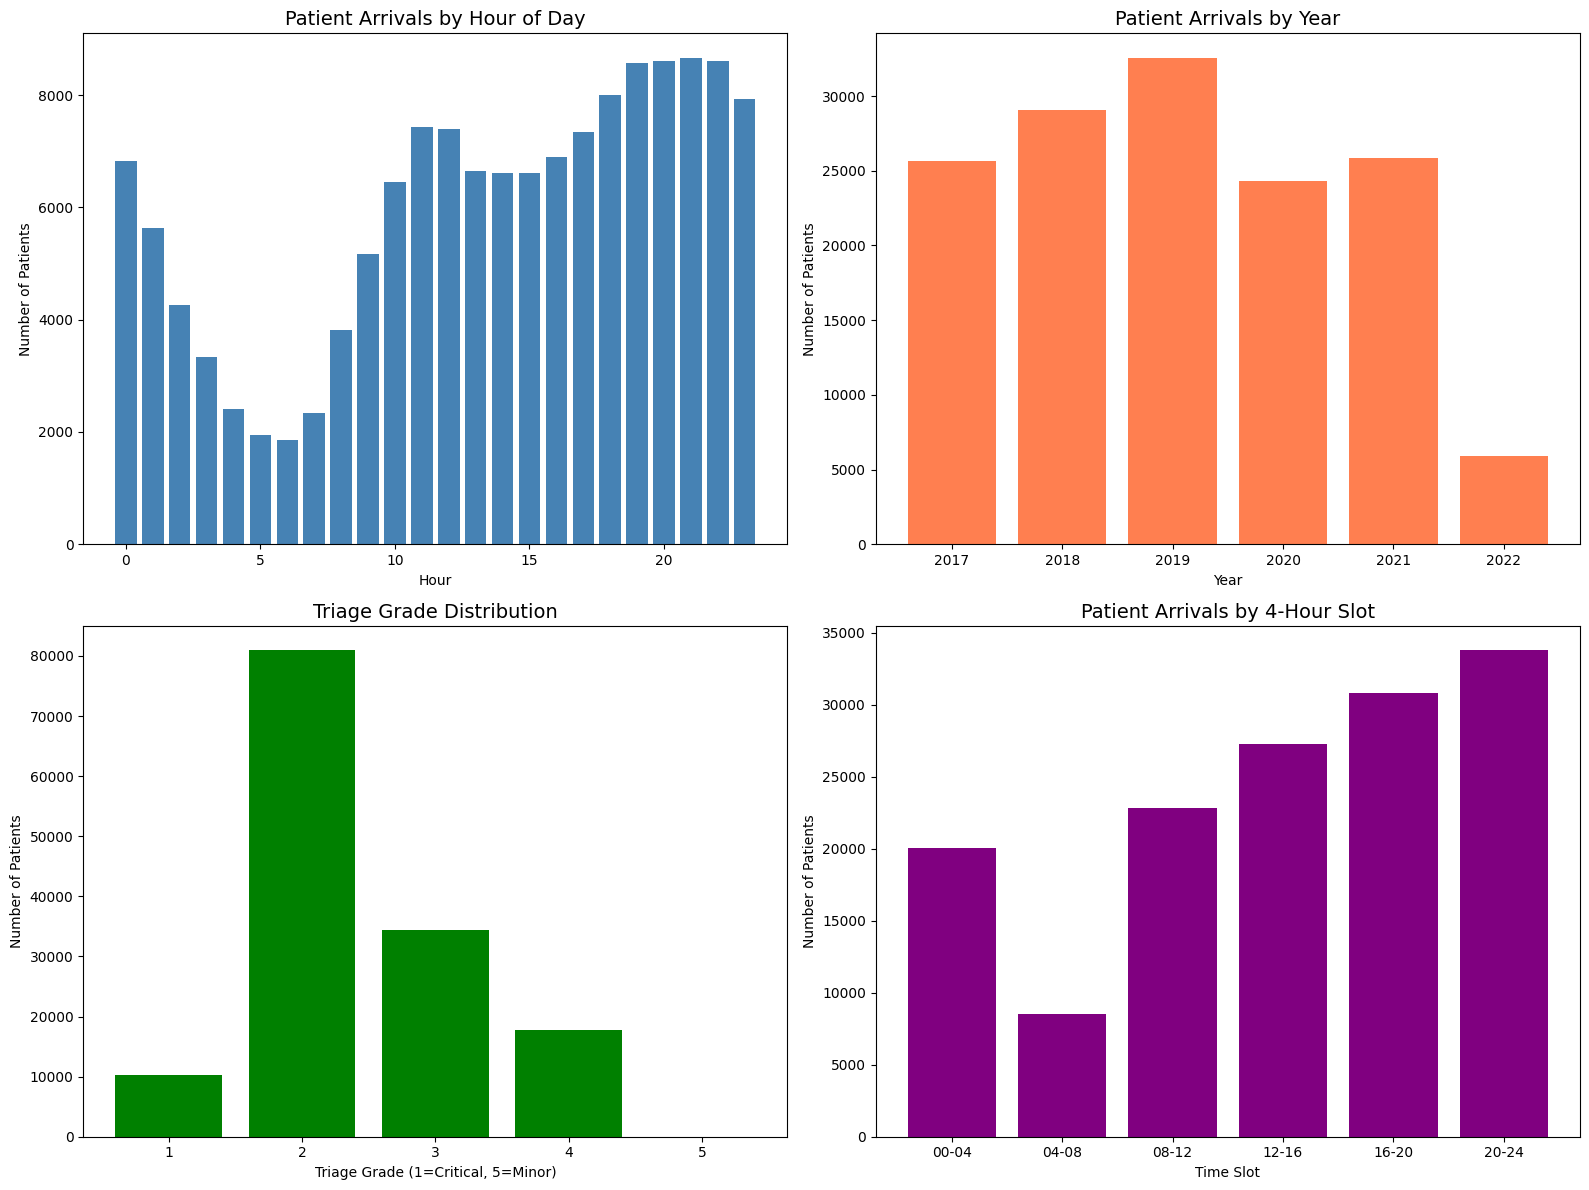

Done


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load triage file
triage = pd.read_csv('ED_triage.csv')

# Deduplicate - keep first record per triage_code
triage = triage.sort_values(['admission_year', 'admission_month',
                              'admission_day', 'admission_hour'])
triage = triage.drop_duplicates(subset='triage_code', keep='first')
print('Clean dataset:', len(triage))

# Create 4-hour time slots
triage['hour_slot'] = (triage['admission_hour'] // 4) * 4
triage['slot_label'] = triage['hour_slot'].map({
    0: '00-04', 4: '04-08', 8: '08-12',
    12: '12-16', 16: '16-20', 20: '20-24'
})

# Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1 - Arrivals by hour
hour_counts = triage['admission_hour'].value_counts().sort_index()
axes[0,0].bar(hour_counts.index, hour_counts.values, color='steelblue')
axes[0,0].set_title('Patient Arrivals by Hour of Day', fontsize=14)
axes[0,0].set_xlabel('Hour')
axes[0,0].set_ylabel('Number of Patients')

# Plot 2 - Arrivals by year
year_counts = triage['admission_year'].value_counts().sort_index()
axes[0,1].bar(year_counts.index, year_counts.values, color='coral')
axes[0,1].set_title('Patient Arrivals by Year', fontsize=14)
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Number of Patients')

# Plot 3 - Triage grade
grade_counts = triage['TriageGrade'].value_counts().sort_index()
axes[1,0].bar(grade_counts.index, grade_counts.values, color='green')
axes[1,0].set_title('Triage Grade Distribution', fontsize=14)
axes[1,0].set_xlabel('Triage Grade (1=Critical, 5=Minor)')
axes[1,0].set_ylabel('Number of Patients')

# Plot 4 - Arrivals by 4-hour slot
slot_counts = triage['slot_label'].value_counts().sort_index()
axes[1,1].bar(slot_counts.index, slot_counts.values, color='purple')
axes[1,1].set_title('Patient Arrivals by 4-Hour Slot', fontsize=14)
axes[1,1].set_xlabel('Time Slot')
axes[1,1].set_ylabel('Number of Patients')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()
print('Done')

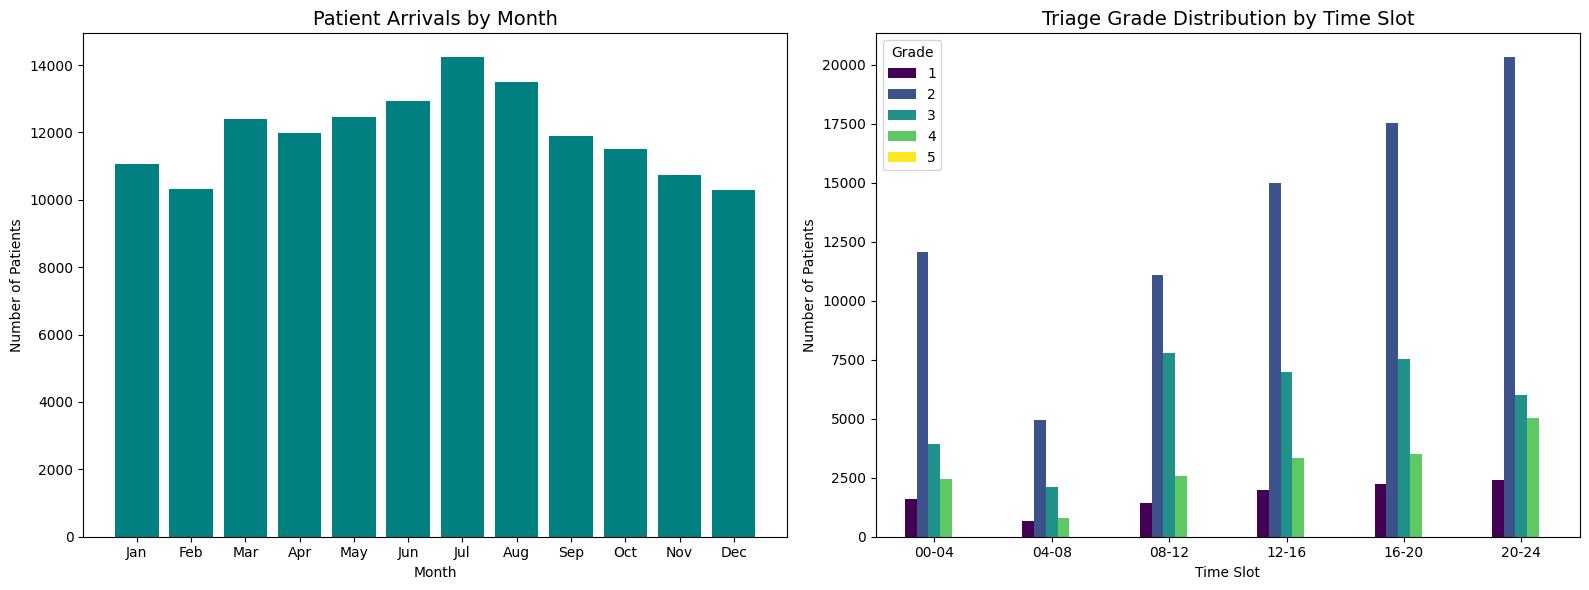

Done


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 - Arrivals by month
month_counts = triage['admission_month'].value_counts().sort_index()
axes[0].bar(month_counts.index, month_counts.values, color='teal')
axes[0].set_title('Patient Arrivals by Month', fontsize=14)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Patients')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])

# Plot 2 - Triage grade by hour slot
import seaborn as sns
grade_slot = triage.groupby(['slot_label', 'TriageGrade']).size().unstack()
grade_slot.plot(kind='bar', ax=axes[1], colormap='viridis')
axes[1].set_title('Triage Grade Distribution by Time Slot', fontsize=14)
axes[1].set_xlabel('Time Slot')
axes[1].set_ylabel('Number of Patients')
axes[1].legend(title='Grade')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_plots2.png', dpi=150)
plt.show()
print('Done')

In [ ]:
# Create daily time series aggregated by 4-hour slot
ts = triage.groupby(['admission_year', 'admission_month',
                     'admission_day', 'slot_label']).size().reset_index()
ts.columns = ['year', 'month', 'day', 'slot', 'patient_count']

# Create proper datetime
ts['date'] = pd.to_datetime(ts[['year', 'month', 'day']])
ts = ts.sort_values(['date', 'slot'])

print('Time series shape:', ts.shape)
print('Date range:', ts['date'].min(), 'to', ts['date'].max())
print(ts.head(12))

Time series shape: (10794, 6)
Date range: 2017-03-21 00:00:00 to 2022-03-20 00:00:00
    year  month  day   slot  patient_count       date
0   2017      3   21  00-04              8 2017-03-21
1   2017      3   21  04-08             11 2017-03-21
2   2017      3   21  08-12             16 2017-03-21
3   2017      3   21  12-16             21 2017-03-21
4   2017      3   21  16-20             26 2017-03-21
5   2017      3   21  20-24             21 2017-03-21
6   2017      3   22  00-04             10 2017-03-22
7   2017      3   22  04-08              8 2017-03-22
8   2017      3   22  08-12             20 2017-03-22
9   2017      3   22  12-16             18 2017-03-22
10  2017      3   22  16-20             26 2017-03-22
11  2017      3   22  20-24             25 2017-03-22


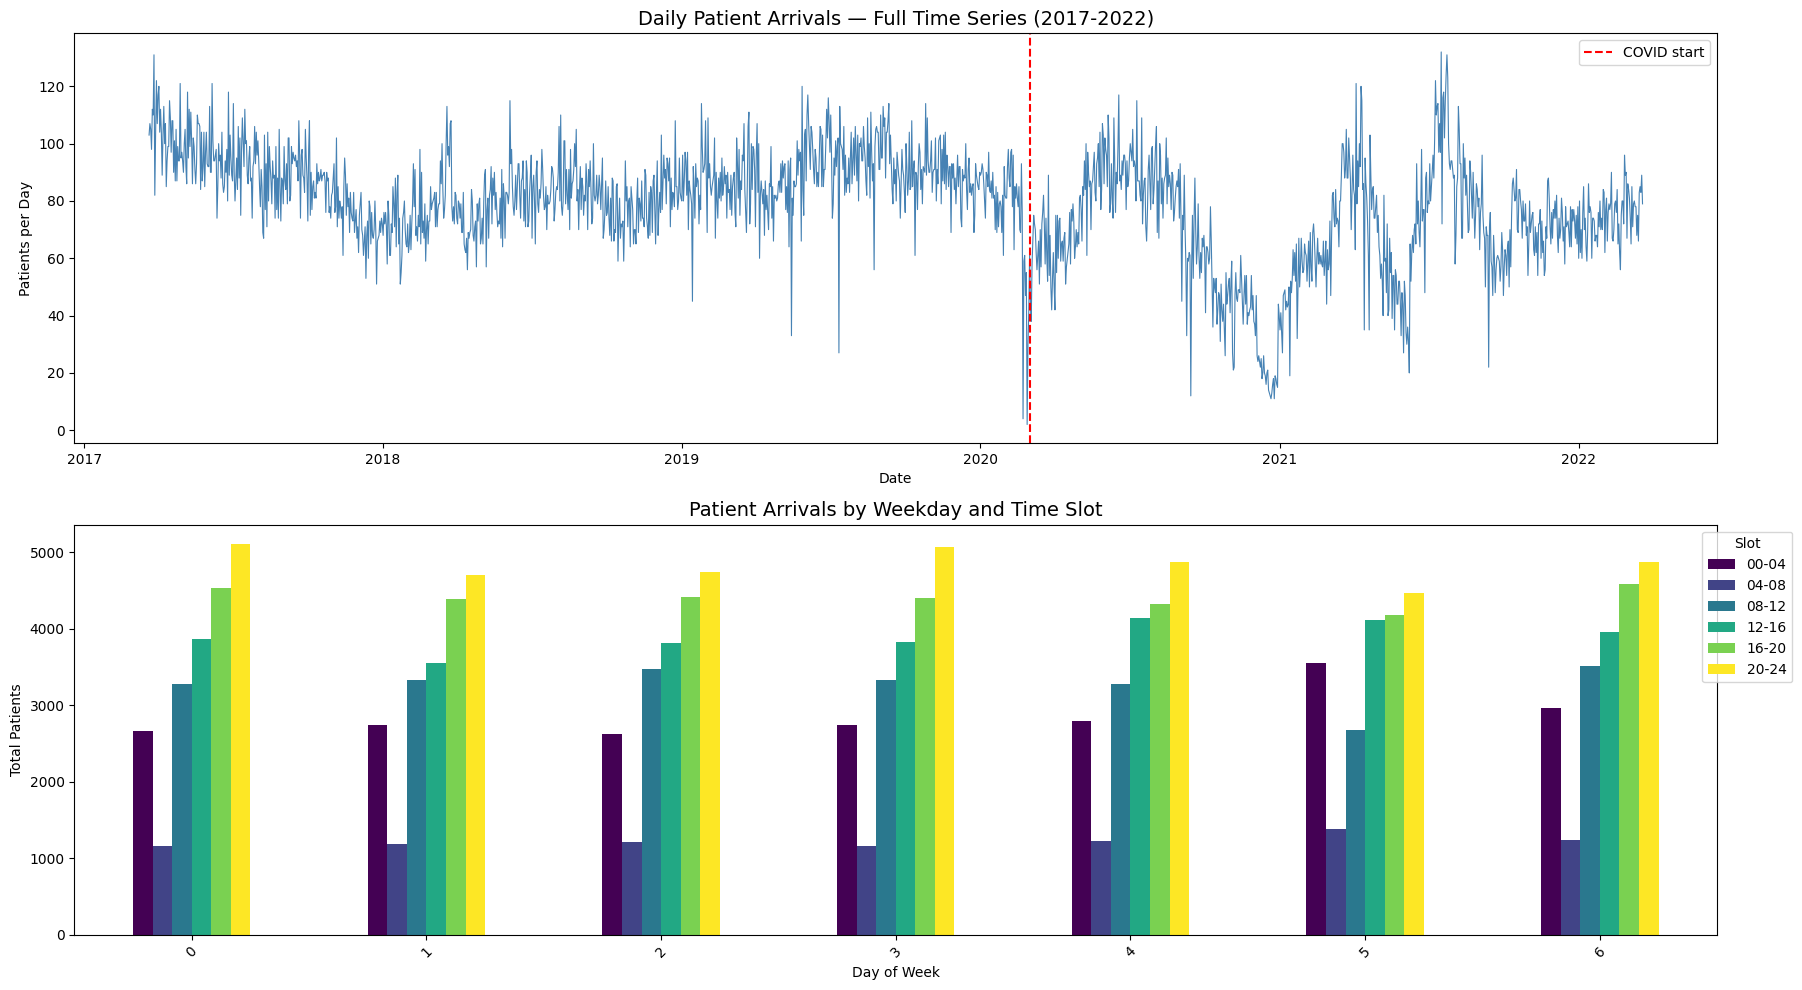

Done


In [ ]:
import matplotlib.pyplot as plt

# Plot daily total patients over time
daily = triage.groupby(['admission_year', 'admission_month', 'admission_day']).size().reset_index()
daily.columns = ['year', 'month', 'day', 'total']
daily['date'] = pd.to_datetime(daily[['year', 'month', 'day']])
daily = daily.sort_values('date')

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Plot 1 - Full time series
axes[0].plot(daily['date'], daily['total'], color='steelblue', linewidth=0.8)
axes[0].set_title('Daily Patient Arrivals — Full Time Series (2017-2022)', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Patients per Day')
axes[0].axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', label='COVID start')
axes[0].legend()

# Plot 2 - Average patients per slot per day of week
dow = triage.groupby(['admission_weekday', 'slot_label']).size().reset_index()
dow.columns = ['weekday', 'slot', 'count']
pivot = dow.pivot(index='weekday', columns='slot', values='count')
pivot.plot(kind='bar', ax=axes[1], colormap='viridis')
axes[1].set_title('Patient Arrivals by Weekday and Time Slot', fontsize=14)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Total Patients')
axes[1].legend(title='Slot', bbox_to_anchor=(1.05, 1))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('timeseries_plot.png', dpi=150)
plt.show()
print('Done')

In [ ]:
print(triage['admission_weekday'].value_counts().sort_index())

admission_weekday
0    20582
1    19882
2    20277
3    20517
4    20611
5    20358
6    21119
Name: count, dtype: int64


In [ ]:
# Check what day of week March 21, 2017 was
import datetime
date = datetime.date(2017, 3, 21)
print('March 21, 2017 was a:', date.strftime('%A'))

# Check what weekday value that date has in our dataset
sample = triage[(triage['admission_year']==2017) &
                (triage['admission_month']==3) &
                (triage['admission_day']==21)]
print('Weekday value in dataset:', sample['admission_weekday'].iloc[0])

March 21, 2017 was a: Tuesday
Weekday value in dataset: 2


In [ ]:
# Add hour slot number
triage['hour_slot_num'] = triage['admission_hour'] // 4

# Aggregate: count patients per day per 4-hour slot
features = triage.groupby(['admission_year', 'admission_month',
                           'admission_day', 'admission_weekday',
                           'hour_slot_num']).size().reset_index()
features.columns = ['year', 'month', 'day', 'day_of_week',
                    'hour_slot', 'patient_count']

# Create date column
features['date'] = pd.to_datetime(features[['year', 'month', 'day']])
features = features.sort_values(['date', 'hour_slot']).reset_index(drop=True)

# Add time features
features['day_of_year'] = features['date'].dt.dayofyear
features['week_of_year'] = features['date'].dt.isocalendar().week.astype(int)
features['is_covid'] = ((features['year'] == 2020) |
                        (features['year'] == 2021)).astype(int)

print('Features shape:', features.shape)
print(features.head(10))

Features shape: (10794, 10)
   year  month  day  day_of_week  hour_slot  patient_count       date  \
0  2017      3   21            2          0              8 2017-03-21   
1  2017      3   21            2          1             11 2017-03-21   
2  2017      3   21            2          2             16 2017-03-21   
3  2017      3   21            2          3             21 2017-03-21   
4  2017      3   21            2          4             26 2017-03-21   
5  2017      3   21            2          5             21 2017-03-21   
6  2017      3   22            3          0             10 2017-03-22   
7  2017      3   22            3          1              8 2017-03-22   
8  2017      3   22            3          2             20 2017-03-22   
9  2017      3   22            3          3             18 2017-03-22   

   day_of_year  week_of_year  is_covid  
0           80            12         0  
1           80            12         0  
2           80            12         0  
3   

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import numpy as np

train = features[features['year'] <= 2020]
test = features[features['year'] >= 2021]

X_train = train[['month', 'day_of_week', 'hour_slot',
                  'day_of_year', 'week_of_year', 'is_covid']]
y_train = train['patient_count']

X_test = test[['month', 'day_of_week', 'hour_slot',
                'day_of_year', 'week_of_year', 'is_covid']]
y_test = test['patient_count']

print('Train size:', len(X_train))
print('Test size:', len(X_test))

model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f'\nMAE: {mae:.2f} patients')
print(f'RMSE: {rmse:.2f} patients')
print(f'MAPE: {mape:.2f}%')

Train size: 8163
Test size: 2631

MAE: 4.61 patients
RMSE: 5.98 patients
MAPE: 57.99%


In [ ]:
# Retrain excluding COVID period completely
train_clean = features[features['year'] <= 2019]
test_clean = features[features['year'] == 2022]  # post-COVID only

X_train_c = train_clean[['month', 'day_of_week', 'hour_slot',
                          'day_of_year', 'week_of_year', 'is_covid']]
y_train_c = train_clean['patient_count']

X_test_c = test_clean[['month', 'day_of_week', 'hour_slot',
                        'day_of_year', 'week_of_year', 'is_covid']]
y_test_c = test_clean['patient_count']

model2 = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05,
                           max_depth=6, random_state=42)
model2.fit(X_train_c, y_train_c)
y_pred_c = model2.predict(X_test_c)

mae2 = mean_absolute_error(y_test_c, y_pred_c)
rmse2 = np.sqrt(mean_squared_error(y_test_c, y_pred_c))
mape2 = np.mean(np.abs((y_test_c - y_pred_c) / y_test_c)) * 100

print(f'Clean MAE: {mae2:.2f} patients')
print(f'Clean RMSE: {rmse2:.2f} patients')
print(f'Clean MAPE: {mape2:.2f}%')

Clean MAE: 3.47 patients
Clean RMSE: 4.64 patients
Clean MAPE: 41.40%


In [ ]:
# Check MAPE by slot to see which slots are problematic
test_clean2 = test_clean.copy()
test_clean2['predicted'] = y_pred_c
test_clean2['mape'] = np.abs((test_clean2['patient_count'] - test_clean2['predicted']) / test_clean2['patient_count']) * 100

print('MAPE by time slot:')
print(test_clean2.groupby('hour_slot')['mape'].mean().round(2))
print()
print('Average patients by slot:')
print(test_clean2.groupby('hour_slot')['patient_count'].mean().round(2))

MAPE by time slot:
hour_slot
0    32.92
1    81.21
2    31.51
3    35.46
4    45.87
5    21.46
Name: mape, dtype: float64

Average patients by slot:
hour_slot
0     9.95
1     4.27
2    12.48
3    14.48
4    15.25
5    18.29
Name: patient_count, dtype: float64


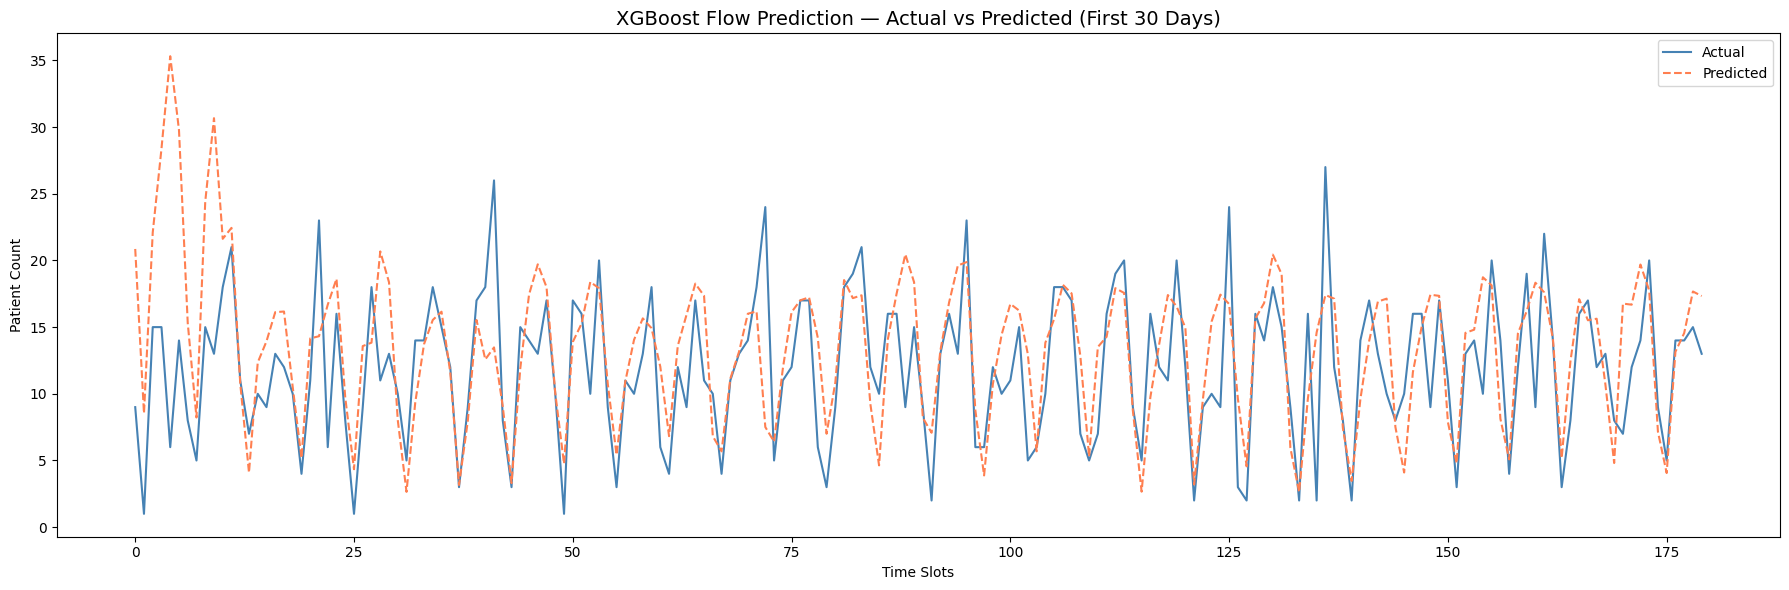

Done


In [ ]:
import matplotlib.pyplot as plt

sample = test_clean2.head(180)

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(range(len(sample)), sample['patient_count'],
        label='Actual', color='steelblue', linewidth=1.5)
ax.plot(range(len(sample)), sample['predicted'],
        label='Predicted', color='coral', linewidth=1.5, linestyle='--')
ax.set_title('XGBoost Flow Prediction — Actual vs Predicted (First 30 Days)', fontsize=14)
ax.set_xlabel('Time Slots')
ax.set_ylabel('Patient Count')
ax.legend()
plt.tight_layout()
plt.savefig('prediction_plot.png', dpi=150)
plt.show()
print('Done')

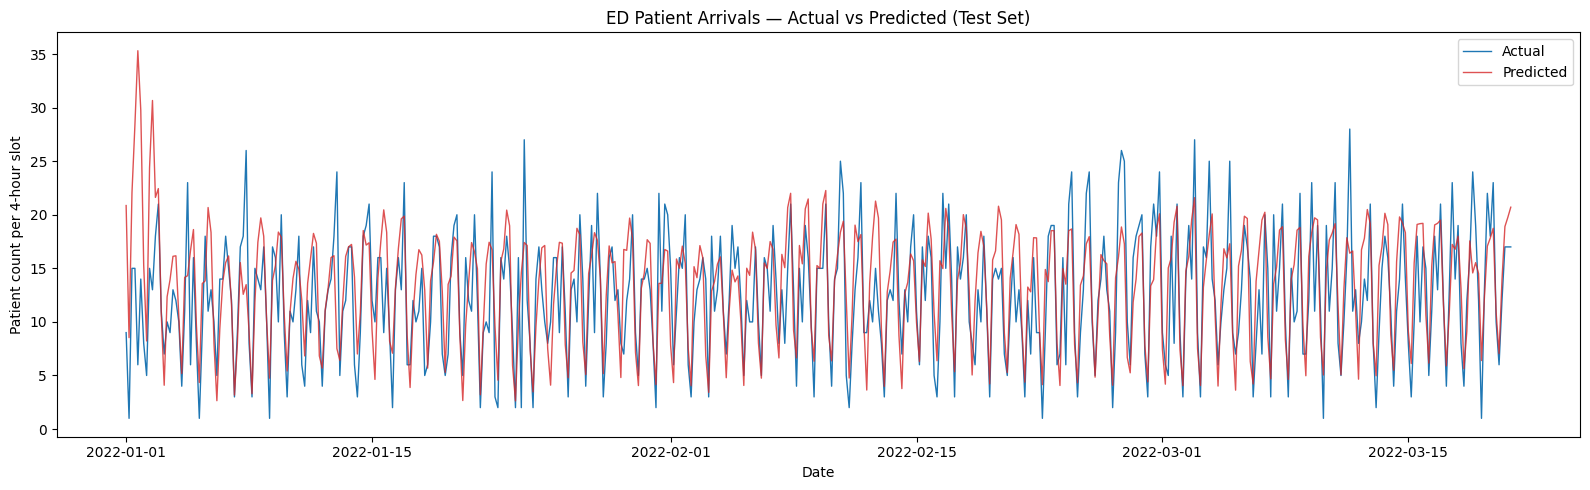

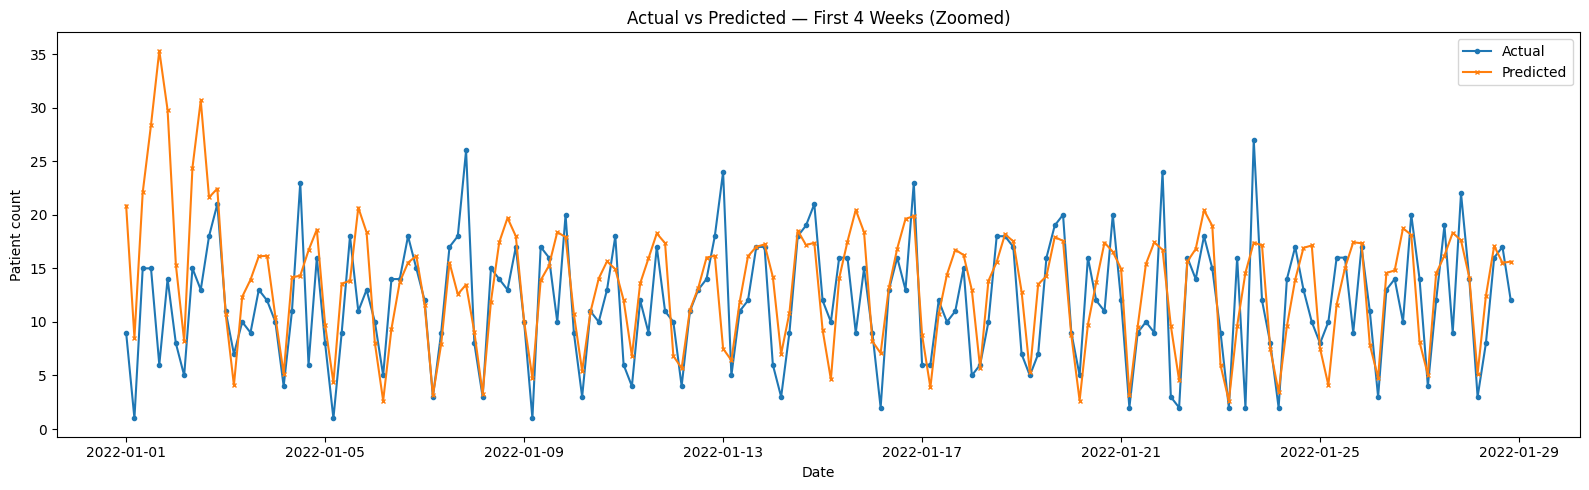

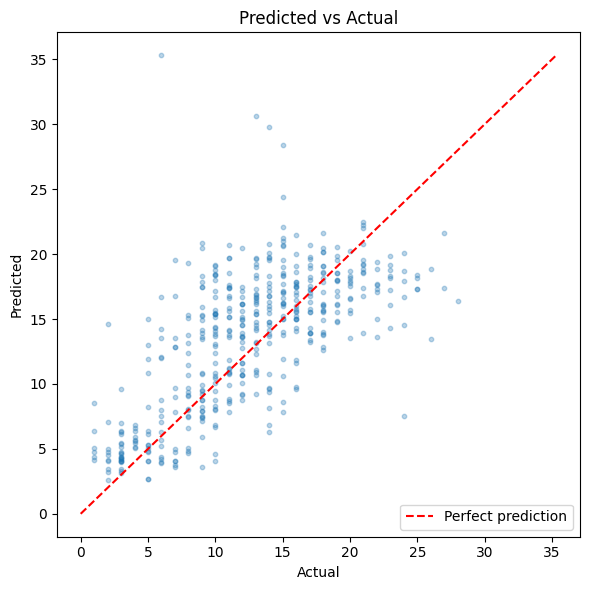

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

slot_start_hour = {0: 0, 1: 4, 2: 8, 3: 12, 4: 16, 5: 20}

test_clean2 = test_clean2.copy()
test_clean2['plot_time'] = pd.to_datetime(test_clean2['date']) + pd.to_timedelta(
    test_clean2['hour_slot'].map(slot_start_hour), unit='h'
)
test_clean2 = test_clean2.sort_values('plot_time')

# Plot 1 — full test period
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test_clean2['plot_time'], test_clean2['patient_count'], label='Actual', color='#1f77b4', linewidth=1)
ax.plot(test_clean2['plot_time'], test_clean2['predicted'], label='Predicted', color='#d62728', linewidth=1, alpha=0.8)
ax.set_title('ED Patient Arrivals — Actual vs Predicted (Test Set)')
ax.set_xlabel('Date')
ax.set_ylabel('Patient count per 4-hour slot')
ax.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted_full.png', dpi=300)
plt.show()

# Plot 2 — zoomed 4-week window
zoom = test_clean2.iloc[:6*7*4]  # 6 slots/day × 7 days × 4 weeks
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(zoom['plot_time'], zoom['patient_count'], label='Actual', marker='o', markersize=3)
ax.plot(zoom['plot_time'], zoom['predicted'], label='Predicted', marker='x', markersize=3)
ax.set_title('Actual vs Predicted — First 4 Weeks (Zoomed)')
ax.set_xlabel('Date')
ax.set_ylabel('Patient count')
ax.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted_zoom.png', dpi=300)
plt.show()

# Plot 3 — scatter with perfect-prediction line
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(test_clean2['patient_count'], test_clean2['predicted'], alpha=0.3, s=10)
max_val = max(test_clean2['patient_count'].max(), test_clean2['predicted'].max())
ax.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title('Predicted vs Actual')
ax.legend()
plt.tight_layout()
plt.savefig('scatter_actual_vs_predicted.png', dpi=300)
plt.show()

In [ ]:
%whos DataFrame

Variable       Type         Data/Info
-------------------------------------
X_test         DataFrame           month  day_of_week<...>\n[2631 rows x 6 columns]
X_test_c       DataFrame           month  day_of_week<...>n\n[474 rows x 6 columns]
X_train        DataFrame          month  day_of_week <...>\n[8163 rows x 6 columns]
X_train_c      DataFrame          month  day_of_week <...>\n[6061 rows x 6 columns]
admission      DataFrame            triage_code  Pati<...>143280 rows x 26 columns]
daily          DataFrame          year  month  day  t<...>\n[1815 rows x 5 columns]
df             DataFrame            triage_code gende<...>143224 rows x 53 columns]
dow            DataFrame        weekday   slot  count<...>41        6  20-24   4866
dupes          DataFrame            triage_code  gend<...>\n[442 rows x 28 columns]
dupes_sorted   DataFrame            triage_code gende<...>\n[540 rows x 53 columns]
features       DataFrame           year  month  day  <...>[10794 rows x 10 columns]


In [ ]:
print(test_clean2.columns.tolist())

['year', 'month', 'day', 'day_of_week', 'hour_slot', 'patient_count', 'date', 'day_of_year', 'week_of_year', 'is_covid', 'predicted', 'mape', 'plot_time']


In [ ]:
test_clean2[test_clean2['date'].between('2022-01-01','2022-01-03')][
    ['date','hour_slot','patient_count','predicted','day_of_week','is_covid']
]

,date,hour_slot,patient_count,predicted,day_of_week,is_covid
10320,2022-01-01,0,9,20.860205,6,0
10321,2022-01-01,1,1,8.531731,6,0
10322,2022-01-01,2,15,22.083897,6,0
10323,2022-01-01,3,15,28.382576,6,0
10324,2022-01-01,4,6,35.311394,6,0
10325,2022-01-01,5,14,29.773167,6,0
10326,2022-01-02,0,8,15.310696,0,0
10327,2022-01-02,1,5,8.224017,0,0
10328,2022-01-02,2,15,24.403856,0,0
10329,2022-01-02,3,13,30.666155,0,0


In [ ]:
test_clean2.head()

,year,month,day,day_of_week,hour_slot,patient_count,date,day_of_year,week_of_year,is_covid,predicted,mape,plot_time
10320,2022,1,1,6,0,9,2022-01-01,1,52,0,20.860205,131.780052,2022-01-01 00:00:00
10321,2022,1,1,6,1,1,2022-01-01,1,52,0,8.531731,753.173065,2022-01-01 04:00:00
10322,2022,1,1,6,2,15,2022-01-01,1,52,0,22.083897,47.225978,2022-01-01 08:00:00
10323,2022,1,1,6,3,15,2022-01-01,1,52,0,28.382576,89.217173,2022-01-01 12:00:00
10324,2022,1,1,6,4,6,2022-01-01,1,52,0,35.311394,488.523229,2022-01-01 16:00:00


In [ ]:
# How far off is each prediction, in plain terms?
test_clean2['error'] = abs(test_clean2['patient_count'] - test_clean2['predicted'])

# Split rows into "good guesses" vs "bad guesses"
good = test_clean2[test_clean2['error'] <= 5]   # within 5 patients of the truth
bad = test_clean2[test_clean2['error'] > 5]      # off by more than 5 patients

print(f"Total rows: {len(test_clean2)}")
print(f"Good guesses (within 5 patients): {len(good)} ({len(good)/len(test_clean2)*100:.1f}%)")
print(f"Bad guesses (off by more than 5): {len(bad)} ({len(bad)/len(test_clean2)*100:.1f}%)")

Total rows: 474
Good guesses (within 5 patients): 356 (75.1%)
Bad guesses (off by more than 5): 118 (24.9%)


In [ ]:
train_clean[(train_clean['month']==1) & (train_clean['day']<=3)][
    ['year','month','day','hour_slot','day_of_week','patient_count']
].sort_values(['year','day','hour_slot'])

,year,month,day,hour_slot,day_of_week,patient_count
1716,2018,1,1,0,1,12
1717,2018,1,1,1,1,2
1718,2018,1,1,2,1,10
1719,2018,1,1,3,1,15
1720,2018,1,1,4,1,18
1721,2018,1,1,5,1,11
1722,2018,1,2,0,2,10
1723,2018,1,2,1,2,6
1724,2018,1,2,2,2,15
1725,2018,1,2,3,2,13


In [ ]:
features = features.sort_values(['date', 'hour_slot'])

features['lag_4wk_avg'] = (
    features.groupby(['day_of_week', 'hour_slot'])['patient_count']
    .transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
)

In [ ]:
features[['date', 'day_of_week', 'hour_slot', 'patient_count', 'lag_4wk_avg']].head(20)

,date,day_of_week,hour_slot,patient_count,lag_4wk_avg
0,2017-03-21,2,0,8,NaN
1,2017-03-21,2,1,11,NaN
2,2017-03-21,2,2,16,NaN
3,2017-03-21,2,3,21,NaN
4,2017-03-21,2,4,26,NaN
5,2017-03-21,2,5,21,NaN
6,2017-03-22,3,0,10,NaN
7,2017-03-22,3,1,8,NaN
8,2017-03-22,3,2,20,NaN
9,2017-03-22,3,3,18,NaN


In [ ]:
features[['date', 'day_of_week', 'hour_slot', 'patient_count', 'lag_4wk_avg']].iloc[40:50]

,date,day_of_week,hour_slot,patient_count,lag_4wk_avg
40,2017-03-27,1,4,29,NaN
41,2017-03-27,1,5,30,NaN
42,2017-03-28,2,0,7,8.0
43,2017-03-28,2,1,8,11.0
44,2017-03-28,2,2,10,16.0
45,2017-03-28,2,3,18,21.0
46,2017-03-28,2,4,17,26.0
47,2017-03-28,2,5,22,21.0
48,2017-03-29,3,0,18,10.0
49,2017-03-29,3,1,8,8.0


In [ ]:
features[(features['year']==2022) & (features['month']==1)][
    ['date','day_of_week','hour_slot','patient_count','lag_4wk_avg']
].head(6)

,date,day_of_week,hour_slot,patient_count,lag_4wk_avg
10320,2022-01-01,6,0,9,10.50
10321,2022-01-01,6,1,1,4.50
10322,2022-01-01,6,2,15,10.75
10323,2022-01-01,6,3,15,17.25
10324,2022-01-01,6,4,6,16.50
10325,2022-01-01,6,5,14,15.50


In [ ]:
# Rebuild splits — needed because train_clean/test_clean2 were created
# BEFORE we added lag_4wk_avg, so they don't have it yet
train_clean = features[features['year'] <= 2019]
test_clean2 = features[features['year'] == 2022]

feature_cols = ['month', 'day_of_week', 'hour_slot',
                'day_of_year', 'week_of_year', 'is_covid', 'lag_4wk_avg']

X_train_c = train_clean[feature_cols]
y_train_c = train_clean['patient_count']

X_test_c = test_clean2[feature_cols]
y_test_c = test_clean2['patient_count']

# New model — keeping model2 untouched so we can still compare
model3 = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05,
                           max_depth=6, random_state=42)
model3.fit(X_train_c, y_train_c)
y_pred_c = model3.predict(X_test_c)

mae3 = mean_absolute_error(y_test_c, y_pred_c)
rmse3 = np.sqrt(mean_squared_error(y_test_c, y_pred_c))
mape3 = np.mean(np.abs((y_test_c - y_pred_c) / y_test_c)) * 100

print(f'With lag feature — MAE: {mae3:.2f} patients')
print(f'With lag feature — RMSE: {rmse3:.2f} patients')
print(f'With lag feature — MAPE: {mape3:.2f}%')

With lag feature — MAE: 3.20 patients
With lag feature — RMSE: 4.14 patients
With lag feature — MAPE: 39.29%


In [ ]:
old_feature_cols = ['month', 'day_of_week', 'hour_slot',
                     'day_of_year', 'week_of_year', 'is_covid']

test_clean2['predicted_v1'] = model2.predict(test_clean2[old_feature_cols])
test_clean2['predicted_v2'] = y_pred_c

test_clean2[(test_clean2['month']==1) & (test_clean2['day']<=3)][
    ['date', 'hour_slot', 'patient_count', 'predicted_v1', 'predicted_v2']
]

/tmp/ipykernel_2999/2533039455.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_clean2['predicted_v1'] = model2.predict(test_clean2[old_feature_cols])
/tmp/ipykernel_2999/2533039455.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_clean2['predicted_v2'] = y_pred_c


,date,hour_slot,patient_count,predicted_v1,predicted_v2
10320,2022-01-01,0,9,20.860205,13.686199
10321,2022-01-01,1,1,8.531731,8.860816
10322,2022-01-01,2,15,22.083897,15.309334
10323,2022-01-01,3,15,28.382576,23.268032
10324,2022-01-01,4,6,35.311394,22.620611
10325,2022-01-01,5,14,29.773167,20.981253
10326,2022-01-02,0,8,15.310696,15.486909
10327,2022-01-02,1,5,8.224017,6.192754
10328,2022-01-02,2,15,24.403856,22.138645
10329,2022-01-02,3,13,30.666155,22.398571


In [ ]:
feature_cols_v2 = ['month', 'day_of_week', 'hour_slot',
                    'week_of_year', 'is_covid', 'lag_4wk_avg']

X_train_c = train_clean[feature_cols_v2]
X_test_c = test_clean2[feature_cols_v2]

model4 = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05,
                           max_depth=6, random_state=42)
model4.fit(X_train_c, y_train_c)
y_pred_v4 = model4.predict(X_test_c)

mae4 = mean_absolute_error(y_test_c, y_pred_v4)
rmse4 = np.sqrt(mean_squared_error(y_test_c, y_pred_v4))
mape4 = np.mean(np.abs((y_test_c - y_pred_v4) / y_test_c)) * 100

print(f'Without day_of_year — MAE: {mae4:.2f} patients')
print(f'Without day_of_year — RMSE: {rmse4:.2f} patients')
print(f'Without day_of_year — MAPE: {mape4:.2f}%')

Without day_of_year — MAE: 3.21 patients
Without day_of_year — RMSE: 4.18 patients
Without day_of_year — MAPE: 37.93%


In [ ]:
test_clean2['predicted_v3'] = y_pred_v4

test_clean2[(test_clean2['month']==1) & (test_clean2['day']<=3)][
    ['date', 'hour_slot', 'patient_count', 'predicted_v1', 'predicted_v2', 'predicted_v3']
]

/tmp/ipykernel_2999/2228936136.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_clean2['predicted_v3'] = y_pred_v4


,date,hour_slot,patient_count,predicted_v1,predicted_v2,predicted_v3
10320,2022-01-01,0,9,20.860205,13.686199,9.111696
10321,2022-01-01,1,1,8.531731,8.860816,4.535725
10322,2022-01-01,2,15,22.083897,15.309334,12.903552
10323,2022-01-01,3,15,28.382576,23.268032,19.058920
10324,2022-01-01,4,6,35.311394,22.620611,18.588642
10325,2022-01-01,5,14,29.773167,20.981253,21.528515
10326,2022-01-02,0,8,15.310696,15.486909,10.580453
10327,2022-01-02,1,5,8.224017,6.192754,5.211001
10328,2022-01-02,2,15,24.403856,22.138645,19.134382
10329,2022-01-02,3,13,30.666155,22.398571,20.158983


In [ ]:
naive_pred = test_clean2['lag_4wk_avg']
actual = test_clean2['patient_count']

mae_naive = mean_absolute_error(actual, naive_pred)
rmse_naive = np.sqrt(mean_squared_error(actual, naive_pred))
mape_naive = np.mean(np.abs((actual - naive_pred) / actual)) * 100

print(f'Naive baseline — MAE: {mae_naive:.2f} patients')
print(f'Naive baseline — RMSE: {rmse_naive:.2f} patients')
print(f'Naive baseline — MAPE: {mape_naive:.2f}%')

Naive baseline — MAE: 3.03 patients
Naive baseline — RMSE: 3.96 patients
Naive baseline — MAPE: 33.90%


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    'feature': feature_cols_v2,
    'importance': model4.feature_importances_
}).sort_values('importance', ascending=False)

print(importance)

        feature  importance
5   lag_4wk_avg    0.488499
2     hour_slot    0.342991
3  week_of_year    0.063026
0         month    0.052918
1   day_of_week    0.052566
4      is_covid    0.000000


In [ ]:
feature_cols_v3 = ['hour_slot', 'lag_4wk_avg']

X_train_c = train_clean[feature_cols_v3]
X_test_c = test_clean2[feature_cols_v3]

model5 = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05,
                           max_depth=6, random_state=42)
model5.fit(X_train_c, y_train_c)
y_pred_v5 = model5.predict(X_test_c)

mae5 = mean_absolute_error(y_test_c, y_pred_v5)
rmse5 = np.sqrt(mean_squared_error(y_test_c, y_pred_v5))
mape5 = np.mean(np.abs((y_test_c - y_pred_v5) / y_test_c)) * 100

print(f'Only 2 best features — MAE: {mae5:.2f} patients')
print(f'Only 2 best features — RMSE: {rmse5:.2f} patients')
print(f'Only 2 best features — MAPE: {mape5:.2f}%')

Only 2 best features — MAE: 3.04 patients
Only 2 best features — RMSE: 3.90 patients
Only 2 best features — MAPE: 37.62%


In [ ]:
model6 = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05,
                           max_depth=3, random_state=42)
model6.fit(X_train_c, y_train_c)
y_pred_v6 = model6.predict(X_test_c)

mae6 = mean_absolute_error(y_test_c, y_pred_v6)
rmse6 = np.sqrt(mean_squared_error(y_test_c, y_pred_v6))
mape6 = np.mean(np.abs((y_test_c - y_pred_v6) / y_test_c)) * 100

print(f'Simpler model — MAE: {mae6:.2f} patients')
print(f'Simpler model — RMSE: {rmse6:.2f} patients')
print(f'Simpler model — MAPE: {mape6:.2f}%')

Simpler model — MAE: 3.01 patients
Simpler model — RMSE: 3.85 patients
Simpler model — MAPE: 37.78%


In [ ]:
features = features.sort_values(['date', 'hour_slot'])

features['lag1'] = features['patient_count'].shift(1)

In [ ]:
features[['date', 'hour_slot', 'patient_count', 'lag1']].head(10)

,date,hour_slot,patient_count,lag1
0,2017-03-21,0,8,NaN
1,2017-03-21,1,11,8.0
2,2017-03-21,2,16,11.0
3,2017-03-21,3,21,16.0
4,2017-03-21,4,26,21.0
5,2017-03-21,5,21,26.0
6,2017-03-22,0,10,21.0
7,2017-03-22,1,8,10.0
8,2017-03-22,2,20,8.0
9,2017-03-22,3,18,20.0


In [ ]:
train_clean = features[features['year'] <= 2019]
test_clean2 = features[features['year'] == 2022]

feature_cols_v4 = ['hour_slot', 'lag_4wk_avg', 'lag1']

X_train_c = train_clean[feature_cols_v4]
y_train_c = train_clean['patient_count']

X_test_c = test_clean2[feature_cols_v4]
y_test_c = test_clean2['patient_count']

model7 = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05,
                           max_depth=3, random_state=42)
model7.fit(X_train_c, y_train_c)
y_pred_v7 = model7.predict(X_test_c)

mae7 = mean_absolute_error(y_test_c, y_pred_v7)
rmse7 = np.sqrt(mean_squared_error(y_test_c, y_pred_v7))
mape7 = np.mean(np.abs((y_test_c - y_pred_v7) / y_test_c)) * 100

print(f'With lag1 added — MAE: {mae7:.2f} patients')
print(f'With lag1 added — RMSE: {rmse7:.2f} patients')
print(f'With lag1 added — MAPE: {mape7:.2f}%')

With lag1 added — MAE: 3.01 patients
With lag1 added — RMSE: 3.87 patients
With lag1 added — MAPE: 37.88%


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
model_rf.fit(X_train_c, y_train_c)
y_pred_rf = model_rf.predict(X_test_c)

mae_rf = mean_absolute_error(y_test_c, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_c, y_pred_rf))
mape_rf = np.mean(np.abs((y_test_c - y_pred_rf) / y_test_c)) * 100

print(f'Random Forest — MAE: {mae_rf:.2f} patients')
print(f'Random Forest — RMSE: {rmse_rf:.2f} patients')
print(f'Random Forest — MAPE: {mape_rf:.2f}%')

Random Forest — MAE: 2.99 patients
Random Forest — RMSE: 3.86 patients
Random Forest — MAPE: 37.43%


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

# --- Build features ---
features = features.sort_values(['date', 'hour_slot'])
grouped = features.groupby(['day_of_week', 'hour_slot'])['patient_count']

# Individual previous 4 weekly values (instead of blended average)
features['lag_w1'] = grouped.shift(1)   # same slot, 1 week ago
features['lag_w2'] = grouped.shift(2)   # same slot, 2 weeks ago
features['lag_w3'] = grouped.shift(3)   # same slot, 3 weeks ago
features['lag_w4'] = grouped.shift(4)   # same slot, 4 weeks ago

# Trend: are recent weeks climbing or dropping? (positive = climbing)
features['trend'] = features['lag_w1'] - features['lag_w4']

# Volatility: how much do the last 4 weeks vary? (high = unstable slot)
features['std_4wk'] = features[['lag_w1', 'lag_w2', 'lag_w3', 'lag_w4']].std(axis=1)

# --- Rebuild splits ---
train_clean = features[features['year'] <= 2019]
test_clean2 = features[features['year'] == 2022]

feature_cols_v6 = ['hour_slot', 'lag_w1', 'lag_w2', 'lag_w3', 'lag_w4', 'trend', 'std_4wk']

X_train_c = train_clean[feature_cols_v6]
y_train_c = train_clean['patient_count']
X_test_c = test_clean2[feature_cols_v6]
y_test_c = test_clean2['patient_count']

# --- Train ---
model9 = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05,
                           max_depth=3, random_state=42)
model9.fit(X_train_c, y_train_c)
y_pred_v9 = model9.predict(X_test_c)

mae9 = mean_absolute_error(y_test_c, y_pred_v9)
rmse9 = np.sqrt(mean_squared_error(y_test_c, y_pred_v9))
mape9 = np.mean(np.abs((y_test_c - y_pred_v9) / y_test_c)) * 100

# --- Compare ---
results = pd.DataFrame({
    'Model': ['Naive baseline', 'model6 (best so far)', 'model9 (this test)'],
    'MAE': [3.03, 3.01, mae9],
    'RMSE': [3.96, 3.85, rmse9],
    'MAPE': [33.90, 37.78, mape9]
})
print(results.to_string(index=False))

               Model      MAE     RMSE      MAPE
      Naive baseline 3.030000 3.960000 33.900000
model6 (best so far) 3.010000 3.850000 37.780000
  model9 (this test) 3.019619 3.899107 38.146543


In [ ]:
features = features.sort_values(['date', 'hour_slot'])
grouped = features.groupby(['day_of_week', 'hour_slot'])['patient_count']

# Recency-weighted average: recent weeks count more than older ones
# shift(1) first (no leakage), then exponentially-weighted mean over past values
features['lag_ewm'] = grouped.transform(lambda x: x.shift(1).ewm(span=4, min_periods=1).mean())

train_clean = features[features['year'] <= 2019]
test_clean2 = features[features['year'] == 2022]

feature_cols_v7 = ['hour_slot', 'lag_ewm']

X_train_c = train_clean[feature_cols_v7]
y_train_c = train_clean['patient_count']
X_test_c = test_clean2[feature_cols_v7]
y_test_c = test_clean2['patient_count']

model10 = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05,
                            max_depth=3, random_state=42)
model10.fit(X_train_c, y_train_c)
y_pred_v10 = model10.predict(X_test_c)

mae10 = mean_absolute_error(y_test_c, y_pred_v10)
rmse10 = np.sqrt(mean_squared_error(y_test_c, y_pred_v10))
mape10 = np.mean(np.abs((y_test_c - y_pred_v10) / y_test_c)) * 100

print(f'Recency-weighted avg — MAE: {mae10:.2f}, RMSE: {rmse10:.2f}, MAPE: {mape10:.2f}%')

Recency-weighted avg — MAE: 3.00, RMSE: 3.87, MAPE: 37.84%


In [ ]:
from sklearn.model_selection import GridSearchCV

feature_cols_final = ['hour_slot', 'lag_4wk_avg']
X_train_c = train_clean[feature_cols_final]
y_train_c = train_clean['patient_count']
X_test_c = test_clean2[feature_cols_final]
y_test_c = test_clean2['patient_count']

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.03, 0.05, 0.1]
}

grid = GridSearchCV(
    xgb.XGBRegressor(random_state=42),
    param_grid,
    scoring='neg_mean_absolute_error',
    cv=5
)
grid.fit(X_train_c, y_train_c)

print('Best params:', grid.best_params_)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_c)

mae_best = mean_absolute_error(y_test_c, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test_c, y_pred_best))
mape_best = np.mean(np.abs((y_test_c - y_pred_best) / y_test_c)) * 100

print(f'Tuned model — MAE: {mae_best:.2f}, RMSE: {rmse_best:.2f}, MAPE: {mape_best:.2f}%')

Best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}
Tuned model — MAE: 3.01, RMSE: 3.86, MAPE: 37.88%


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Rebuild clean split with the winning feature set
feature_cols_final = ['hour_slot', 'lag_4wk_avg']
train_clean = features[features['year'] <= 2019]
test_clean2 = features[features['year'] == 2022]

X_train_c = train_clean[feature_cols_final]
y_train_c = train_clean['patient_count']
X_test_c = test_clean2[feature_cols_final]
y_test_c = test_clean2['patient_count']

# Weight: smaller patient_count → higher weight. +1 avoids divide-by-zero.
sample_weights = 1 / (y_train_c + 1)

model_rf_weighted = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
model_rf_weighted.fit(X_train_c, y_train_c, sample_weight=sample_weights)
y_pred_w = model_rf_weighted.predict(X_test_c)

mae_w = mean_absolute_error(y_test_c, y_pred_w)
rmse_w = np.sqrt(mean_squared_error(y_test_c, y_pred_w))
mape_w = np.mean(np.abs((y_test_c - y_pred_w) / y_test_c)) * 100

print(f'Weighted RF — MAE: {mae_w:.2f}, RMSE: {rmse_w:.2f}, MAPE: {mape_w:.2f}%')

Weighted RF — MAE: 2.88, RMSE: 3.75, MAPE: 31.66%


In [ ]:
test_clean2['error'] = abs(y_test_c - y_pred_w)

good = test_clean2[test_clean2['error'] <= 5]
bad = test_clean2[test_clean2['error'] > 5]

print(f"Total rows: {len(test_clean2)}")
print(f"Good guesses (within 5 patients): {len(good)} ({len(good)/len(test_clean2)*100:.1f}%)")
print(f"Bad guesses (off by more than 5): {len(bad)} ({len(bad)/len(test_clean2)*100:.1f}%)")

Total rows: 474
Good guesses (within 5 patients): 395 (83.3%)
Bad guesses (off by more than 5): 79 (16.7%)


/tmp/ipykernel_615/378233920.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_clean2['error'] = abs(y_test_c - y_pred_w)


In [ ]:
test_clean2 = test_clean2.copy()
test_clean2['residual'] = y_pred_w - y_test_c  # positive = overpredicted, negative = underpredicted

over = test_clean2[test_clean2['residual'] > 0]
under = test_clean2[test_clean2['residual'] < 0]
exact = test_clean2[test_clean2['residual'] == 0]

print(f"Overpredicted (model guessed too high): {len(over)} ({len(over)/len(test_clean2)*100:.1f}%)")
print(f"Underpredicted (model guessed too low): {len(under)} ({len(under)/len(test_clean2)*100:.1f}%)")
print(f"Exact matches: {len(exact)} ({len(exact)/len(test_clean2)*100:.1f}%)")
print()
print(f"Average size of overpredictions: {over['residual'].mean():.2f} patients")
print(f"Average size of underpredictions: {under['residual'].mean():.2f} patients")

Overpredicted (model guessed too high): 239 (50.4%)
Underpredicted (model guessed too low): 235 (49.6%)
Exact matches: 0 (0.0%)

Average size of overpredictions: 2.66 patients
Average size of underpredictions: -3.10 patients


In [ ]:
test_clean2.groupby('hour_slot')['residual'].agg(['mean', 'count'])

,mean,count
hour_slot,,
0,-0.818552,79
1,-0.175901,79
2,-0.533281,79
3,-0.104267,79
4,1.141136,79
5,-0.677169,79


In [ ]:
train_valid = train_clean.dropna(subset=['lag_4wk_avg'])
X_train_c = train_valid[['hour_slot', 'lag_4wk_avg']]
y_train_c = train_valid['patient_count']
sample_weights = 1 / (y_train_c + 1)

model_rf_mae = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
model_rf_mae.fit(X_train_c, y_train_c, sample_weight=sample_weights)
y_pred_mae_crit = model_rf_mae.predict(X_test_c)

mae_c = mean_absolute_error(y_test_c, y_pred_mae_crit)
rmse_c = np.sqrt(mean_squared_error(y_test_c, y_pred_mae_crit))
mape_c = np.mean(np.abs((y_test_c - y_pred_mae_crit) / y_test_c)) * 100

print(f'MAE: {mae_c:.2f}, RMSE: {rmse_c:.2f}, MAPE: {mape_c:.2f}%')

MAE: 2.88, RMSE: 3.76, MAPE: 30.86%


In [ ]:
wape = np.sum(np.abs(y_test_c - y_pred_mae_crit)) / np.sum(y_test_c) * 100
print(f'WAPE: {wape:.2f}%')

WAPE: 23.11%


In [ ]:
avg_underprediction = abs(test_clean2[test_clean2['residual'] < 0]['residual'].mean())  # ~3.10

def forecast_with_buffer(predicted):
    return {
        "predicted_arrivals": round(predicted, 1),
        "recommended_staffing_buffer": round(predicted + avg_underprediction, 1)
    }

# example
forecast_with_buffer(y_pred_mae_crit[0])

{'predicted_arrivals': np.float64(8.8),
 'recommended_staffing_buffer': np.float64(11.9)}

In [ ]:
model_xgb_l1 = xgb.XGBRegressor(
    n_estimators=100, learning_rate=0.05, max_depth=3,
    objective='reg:absoluteerror', random_state=42
)
model_xgb_l1.fit(X_train_c, y_train_c, sample_weight=sample_weights)
y_pred_l1 = model_xgb_l1.predict(X_test_c)

mae_l1 = mean_absolute_error(y_test_c, y_pred_l1)
rmse_l1 = np.sqrt(mean_squared_error(y_test_c, y_pred_l1))
mape_l1 = np.mean(np.abs((y_test_c - y_pred_l1) / y_test_c)) * 100

print(f'MAE: {mae_l1:.2f}, RMSE: {rmse_l1:.2f}, MAPE: {mape_l1:.2f}%')

MAE: 2.89, RMSE: 3.77, MAPE: 31.15%


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

# --- 1. Build the one feature we need ---
features = features.sort_values(['date', 'hour_slot'])
features['lag_4wk_avg'] = (
    features.groupby(['day_of_week', 'hour_slot'])['patient_count']
    .transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
)

# --- 2. Split by year ---
train_clean = features[features['year'] <= 2019].dropna(subset=['lag_4wk_avg'])
test_clean2 = features[features['year'] == 2022]

feature_cols = ['hour_slot', 'lag_4wk_avg']
X_train = train_clean[feature_cols]
y_train = train_clean['patient_count']
X_test = test_clean2[feature_cols]
y_test = test_clean2['patient_count']

# --- 3. Train final model ---
sample_weights = 1 / (y_train + 1)

final_model = RandomForestRegressor(
    n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42
)
final_model.fit(X_train, y_train, sample_weight=sample_weights)

# --- 4. Evaluate ---
y_pred = final_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
wape = np.sum(np.abs(y_test - y_pred)) / np.sum(y_test) * 100

print(f'Final model — MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%, WAPE: {wape:.2f}%')

# --- 5. Save model to disk ---
joblib.dump(final_model, 'flow_prediction_model.pkl')
print('Model saved as flow_prediction_model.pkl')

Final model — MAE: 2.88, RMSE: 3.76, MAPE: 30.86%, WAPE: 23.11%
Model saved as flow_prediction_model.pkl


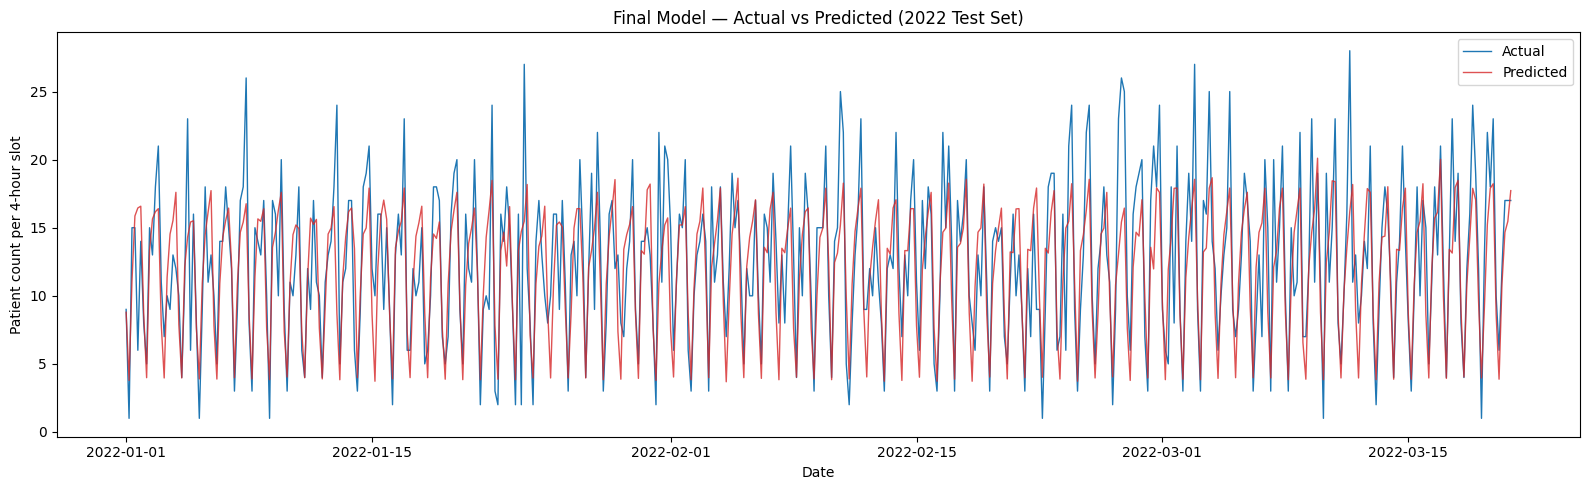

       feature  importance
1  lag_4wk_avg    0.846754
0    hour_slot    0.153246


In [ ]:
import matplotlib.pyplot as plt

test_clean2 = test_clean2.copy()
test_clean2['predicted_final'] = y_pred

slot_start_hour = {0: 0, 1: 4, 2: 8, 3: 12, 4: 16, 5: 20}
test_clean2['plot_time'] = pd.to_datetime(test_clean2['date']) + pd.to_timedelta(
    test_clean2['hour_slot'].map(slot_start_hour), unit='h'
)
test_clean2 = test_clean2.sort_values('plot_time')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test_clean2['plot_time'], test_clean2['patient_count'], label='Actual', color='#1f77b4', linewidth=1)
ax.plot(test_clean2['plot_time'], test_clean2['predicted_final'], label='Predicted', color='#d62728', linewidth=1, alpha=0.8)
ax.set_title('Final Model — Actual vs Predicted (2022 Test Set)')
ax.set_xlabel('Date')
ax.set_ylabel('Patient count per 4-hour slot')
ax.legend()
plt.tight_layout()
plt.savefig('final_actual_vs_predicted.png', dpi=300)
plt.show()

# Feature importance
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)
print(importance)

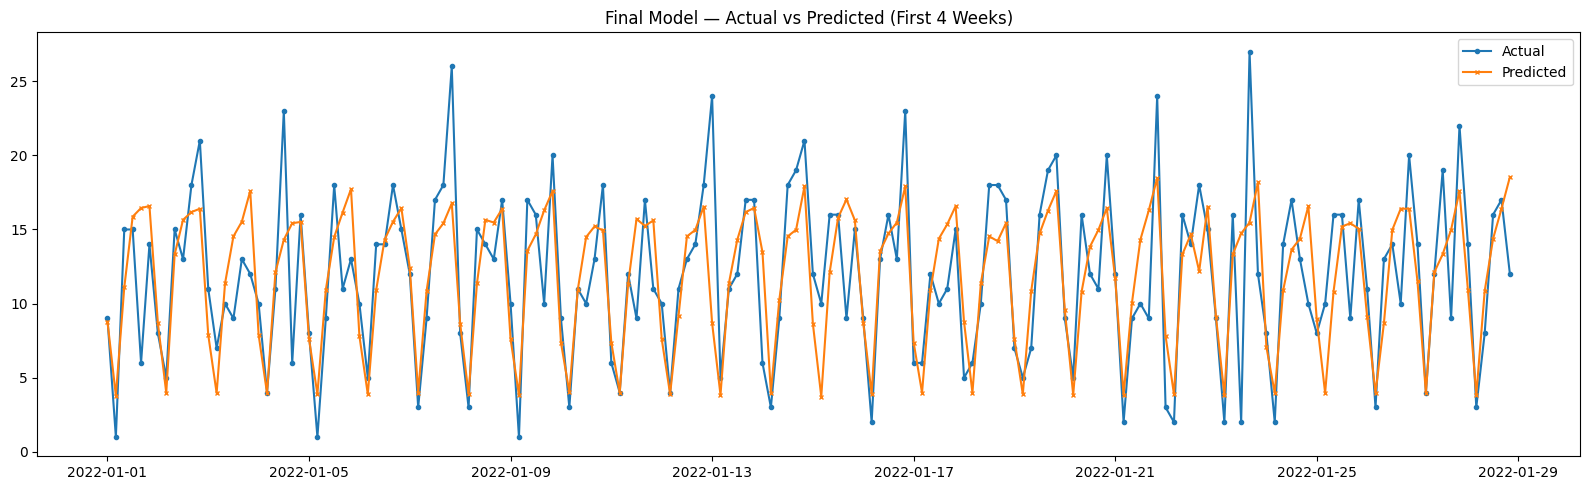

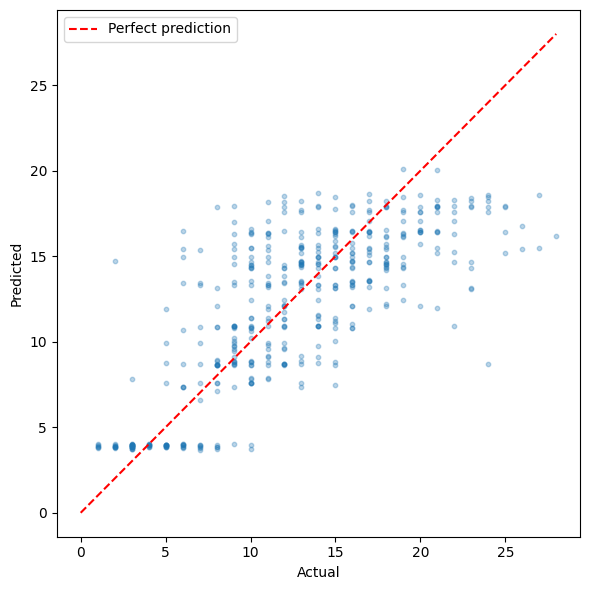

In [ ]:
# Zoomed — first 4 weeks
zoom = test_clean2.iloc[:6*7*4]
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(zoom['plot_time'], zoom['patient_count'], label='Actual', marker='o', markersize=3)
ax.plot(zoom['plot_time'], zoom['predicted_final'], label='Predicted', marker='x', markersize=3)
ax.set_title('Final Model — Actual vs Predicted (First 4 Weeks)')
ax.legend()
plt.tight_layout()
plt.savefig('final_zoom.png', dpi=300)
plt.show()

# Scatter
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(test_clean2['patient_count'], test_clean2['predicted_final'], alpha=0.3, s=10)
max_val = max(test_clean2['patient_count'].max(), test_clean2['predicted_final'].max())
ax.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.legend()
plt.tight_layout()
plt.savefig('final_scatter.png', dpi=300)
plt.show()

In [ ]:
# Try training WITHOUT the weighting, just to see peak performance
model_unweighted = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
model_unweighted.fit(X_train, y_train)  # no sample_weight this time
y_pred_unweighted = model_unweighted.predict(X_test)

# Compare peak performance specifically (top 10% busiest actual slots)
threshold = y_test.quantile(0.9)
peak_mask = y_test >= threshold

mae_peak_weighted = mean_absolute_error(y_test[peak_mask], y_pred[peak_mask])
mae_peak_unweighted = mean_absolute_error(y_test[peak_mask], y_pred_unweighted[peak_mask])

print(f'Peak MAE (weighted model): {mae_peak_weighted:.2f}')
print(f'Peak MAE (unweighted model): {mae_peak_unweighted:.2f}')

Peak MAE (weighted model): 5.85
Peak MAE (unweighted model): 4.82


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

# --- 1. Build the one feature we need ---
features = features.sort_values(['date', 'hour_slot'])
features['lag_4wk_avg'] = (
    features.groupby(['day_of_week', 'hour_slot'])['patient_count']
    .transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
)

# --- 2. Split by year ---
train_clean = features[features['year'] <= 2019].dropna(subset=['lag_4wk_avg'])
test_clean2 = features[features['year'] == 2022]

feature_cols = ['hour_slot', 'lag_4wk_avg']
X_train = train_clean[feature_cols]
y_train = train_clean['patient_count']
X_test = test_clean2[feature_cols]
y_test = test_clean2['patient_count']

# --- 3. Train final model (no sample weighting — prioritizes peak accuracy) ---
final_model = RandomForestRegressor(
    n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42
)
final_model.fit(X_train, y_train)

# --- 4. Evaluate ---
y_pred = final_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
wape = np.sum(np.abs(y_test - y_pred)) / np.sum(y_test) * 100

print(f'Final model — MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%, WAPE: {wape:.2f}%')

# Peak-slot check (top 10% busiest actual slots)
threshold = y_test.quantile(0.9)
peak_mask = y_test >= threshold
mae_peak = mean_absolute_error(y_test[peak_mask], y_pred[peak_mask])
print(f'Peak-slot MAE (busiest 10%): {mae_peak:.2f}')

# --- 5. Save model to disk ---
joblib.dump(final_model, 'flow_prediction_model.pkl')
print('Model saved as flow_prediction_model.pkl')

Final model — MAE: 2.95, RMSE: 3.80, MAPE: 35.89%, WAPE: 23.70%
Peak-slot MAE (busiest 10%): 4.82
Model saved as flow_prediction_model.pkl


In [ ]:
features[['date', 'day_of_week', 'hour_slot', 'patient_count']].to_csv('historical_flow.csv', index=False)

In [ ]:
sample_weights_light = 1 / np.sqrt(y_train + 1)  # gentler than 1/(y+1)

final_model_light = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
final_model_light.fit(X_train, y_train, sample_weight=sample_weights_light)
y_pred_light = final_model_light.predict(X_test)

mae_l = mean_absolute_error(y_test, y_pred_light)
rmse_l = np.sqrt(mean_squared_error(y_test, y_pred_light))
mape_l = np.mean(np.abs((y_test - y_pred_light) / y_test)) * 100

mae_peak_l = mean_absolute_error(y_test[peak_mask], y_pred_light[peak_mask])

print(f'MAE: {mae_l:.2f}, RMSE: {rmse_l:.2f}, MAPE: {mape_l:.2f}%, Peak MAE: {mae_peak_l:.2f}')

MAE: 2.88, RMSE: 3.73, MAPE: 32.63%, Peak MAE: 5.36


In [ ]:
naive_pred = test_clean2['lag_4wk_avg']
mae_peak_naive = mean_absolute_error(y_test[peak_mask], naive_pred[peak_mask])
print(f'Naive Peak MAE: {mae_peak_naive:.2f}')

Naive Peak MAE: 5.99


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

# --- 1. Build feature ---
features = features.sort_values(['date', 'hour_slot'])
features['lag_4wk_avg'] = (
    features.groupby(['day_of_week', 'hour_slot'])['patient_count']
    .transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
)

# --- 2. Split ---
train_clean = features[features['year'] <= 2019].dropna(subset=['lag_4wk_avg'])
test_clean2 = features[features['year'] == 2022]

feature_cols = ['hour_slot', 'lag_4wk_avg']
X_train = train_clean[feature_cols]
y_train = train_clean['patient_count']
X_test = test_clean2[feature_cols]
y_test = test_clean2['patient_count']

# --- 3. Train final model (light weighting) ---
sample_weights = 1 / np.sqrt(y_train + 1)

final_model = RandomForestRegressor(
    n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42
)
final_model.fit(X_train, y_train, sample_weight=sample_weights)

# --- 4. Evaluate ---
y_pred = final_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
wape = np.sum(np.abs(y_test - y_pred)) / np.sum(y_test) * 100

threshold = y_test.quantile(0.9)
peak_mask = y_test >= threshold
mae_peak = mean_absolute_error(y_test[peak_mask], y_pred[peak_mask])

print(f'Final model — MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%, WAPE: {wape:.2f}%, Peak MAE: {mae_peak:.2f}')

# --- 5. Save model + historical data for the endpoint ---
joblib.dump(final_model, 'flow_prediction_model.pkl')
features[['date', 'day_of_week', 'hour_slot', 'patient_count']].to_csv('historical_flow.csv', index=False)
print('Saved: flow_prediction_model.pkl, historical_flow.csv')

Final model — MAE: 2.88, RMSE: 3.73, MAPE: 32.63%, WAPE: 23.12%, Peak MAE: 5.36
Saved: flow_prediction_model.pkl, historical_flow.csv


In [ ]:
from scipy import stats

naive_errors = np.abs(y_test - naive_pred)
model_errors = np.abs(y_test - y_pred)

t_stat, p_value = stats.ttest_rel(naive_errors, model_errors)
print(f'p-value: {p_value:.4f}')

p-value: 0.0068


In [ ]:
triage['ChiefComplaint'].nunique()
triage['ChiefComplaint'].value_counts().head(20)

,count
ChiefComplaint,
U07.1,16994
T07,16484
T79.9,13355
R10.84,10414
R06.00,8567
R07.9,5494
S09.93,4987
R53,4631
T50.901A,4118


In [ ]:
print(triage['ChiefComplaint'].nunique())

897


In [ ]:
triage['icd_chapter'] = triage['ChiefComplaint'].str[0]
print(triage['icd_chapter'].value_counts())

icd_chapter
R    53670
T    39322
U    16994
S     8295
K     5290
N     4142
I     2567
G     2185
Z     2139
M     2135
W     2044
L     1400
E      930
D      643
X      343
J      320
H      260
O      137
F      118
B       89
Y       85
A       73
C       66
0       40
2       20
Q       17
V       11
6        9
P        1
3        1
Name: count, dtype: int64


In [ ]:
triage[triage['icd_chapter'].isin(['0','2','3','6'])]['ChiefComplaint'].unique()

array(['2W3QX1Z', '0WP830Z', '6A550Z3', '2W5TX2Z', '0DHA3UZ', '2Y51X5Z',
       '0BP14FZ', '0DP6XUZ', '0JPT0XZ', '06H00DZ', '0W9G3ZX', '07DR3ZX',
       '0M910ZZ', '0W9840Z', '0B21XFZ', '30233K1'], dtype=object)

In [ ]:
covid_rows = triage[triage['ChiefComplaint'] == 'U07.1']
print(covid_rows['admission_year'].value_counts().sort_index())

admission_year
2020     4695
2021    11414
2022      885
Name: count, dtype: int64


In [ ]:
triage_clean = triage[triage['ChiefComplaint'] != 'U07.1'].copy()
print(len(triage), '→', len(triage_clean))

143346 → 126352


In [ ]:
category_map = {
    'S': 'Trauma/Injury', 'T': 'Trauma/Injury', 'W': 'Trauma/Injury',
    'R': 'Symptoms/General',
    'K': 'Digestive',
    'N': 'Genitourinary',
    'I': 'Cardiac',
    'G': 'Neurological',
    'M': 'Musculoskeletal',
    'Z': 'Administrative/Other',
    'L': 'Skin',
    'E': 'Endocrine/Metabolic',
    'J': 'Respiratory'
}

triage_clean['complaint_category'] = triage_clean['icd_chapter'].map(category_map).fillna('Other/Rare')

print(triage_clean['complaint_category'].value_counts())

complaint_category
Symptoms/General        53670
Trauma/Injury           49661
Digestive                5290
Genitourinary            4142
Cardiac                  2567
Neurological             2185
Administrative/Other     2139
Musculoskeletal          2135
Other/Rare               1913
Skin                     1400
Endocrine/Metabolic       930
Respiratory               320
Name: count, dtype: int64


In [ ]:
print(triage_clean['TriageGrade'].value_counts().sort_index())

TriageGrade
1     7689
2    66966
3    34071
4    17609
5       17
Name: count, dtype: int64


In [ ]:
triage_clean['TriageGrade_merged'] = triage_clean['TriageGrade'].replace(5, 4)

print(triage_clean['TriageGrade_merged'].value_counts().sort_index())

TriageGrade_merged
1     7689
2    66966
3    34071
4    17626
Name: count, dtype: int64


In [ ]:
print(triage_clean[['admission_hour', 'hour_slot']].head(10))

   admission_hour  hour_slot
0               2          0
1               2          0
2               2          0
3               2          0
4               2          0
5               3          0
6               3          0
7               3          0
8               4          4
9               4          4


In [ ]:
triage_clean['date'] = pd.to_datetime(
    triage_clean[['admission_year', 'admission_month', 'admission_day']]
    .rename(columns={'admission_year':'year','admission_month':'month','admission_day':'day'})
)

print(triage_clean[['date','hour_slot']].head(10))

        date  hour_slot
0 2017-03-21          0
1 2017-03-21          0
2 2017-03-21          0
3 2017-03-21          0
4 2017-03-21          0
5 2017-03-21          0
6 2017-03-21          0
7 2017-03-21          0
8 2017-03-21          4
9 2017-03-21          4


In [ ]:
category_dist = (
    triage_clean.groupby(['date', 'hour_slot', 'complaint_category'])
    .size()
    .unstack(fill_value=0)
)

category_dist_pct = category_dist.div(category_dist.sum(axis=1), axis=0)

print(category_dist_pct.head(5))

complaint_category    Administrative/Other  Cardiac  Digestive  \
date       hour_slot                                             
2017-03-21 0                      0.125000      0.0        0.0   
           4                      0.090909      0.0        0.0   
           8                      0.187500      0.0        0.0   
           12                     0.047619      0.0        0.0   
           16                     0.000000      0.0        0.0   

complaint_category    Endocrine/Metabolic  Genitourinary  Musculoskeletal  \
date       hour_slot                                                        
2017-03-21 0                     0.000000       0.125000         0.000000   
           4                     0.090909       0.000000         0.000000   
           8                     0.000000       0.000000         0.000000   
           12                    0.000000       0.000000         0.047619   
           16                    0.000000       0.038462         0.000000  

In [ ]:
print(triage_clean[['hour_slot', 'hour_slot_num', 'slot_label']].head(10))

   hour_slot  hour_slot_num slot_label
0          0              0      00-04
1          0              0      00-04
2          0              0      00-04
3          0              0      00-04
4          0              0      00-04
5          0              0      00-04
6          0              0      00-04
7          0              0      00-04
8          4              1      04-08
9          4              1      04-08


In [ ]:
category_dist = (
    triage_clean.groupby(['date', 'hour_slot_num', 'complaint_category'])
    .size()
    .unstack(fill_value=0)
)

category_dist_pct = category_dist.div(category_dist.sum(axis=1), axis=0)

print(category_dist_pct.head(5))

complaint_category        Administrative/Other  Cardiac  Digestive  \
date       hour_slot_num                                             
2017-03-21 0                          0.125000      0.0        0.0   
           1                          0.090909      0.0        0.0   
           2                          0.187500      0.0        0.0   
           3                          0.047619      0.0        0.0   
           4                          0.000000      0.0        0.0   

complaint_category        Endocrine/Metabolic  Genitourinary  Musculoskeletal  \
date       hour_slot_num                                                        
2017-03-21 0                         0.000000       0.125000         0.000000   
           1                         0.090909       0.000000         0.000000   
           2                         0.000000       0.000000         0.000000   
           3                         0.000000       0.000000         0.047619   
           4           

In [ ]:
severity_dist = (
    triage_clean.groupby(['date', 'hour_slot_num', 'TriageGrade_merged'])
    .size()
    .unstack(fill_value=0)
)

severity_dist_pct = severity_dist.div(severity_dist.sum(axis=1), axis=0)

print(severity_dist_pct.head(5))

TriageGrade_merged               1         2         3         4
date       hour_slot_num                                        
2017-03-21 0              0.000000  0.250000  0.375000  0.375000
           1              0.000000  0.090909  0.545455  0.363636
           2              0.000000  0.625000  0.312500  0.062500
           3              0.000000  0.571429  0.428571  0.000000
           4              0.076923  0.269231  0.538462  0.115385


In [ ]:
triage_clean.groupby(['date','hour_slot_num']).size().groupby('hour_slot_num').mean()

,0
hour_slot_num,
0,10.895449
1,4.857772
2,12.132031
3,14.443368
4,16.684630
5,17.745917


In [ ]:
category_map_4 = {
    'S': 'Trauma/Injury', 'T': 'Trauma/Injury', 'W': 'Trauma/Injury',
    'R': 'Medical/Internal', 'K': 'Medical/Internal', 'N': 'Medical/Internal',
    'I': 'Medical/Internal', 'G': 'Medical/Internal', 'E': 'Medical/Internal', 'J': 'Medical/Internal',
    'M': 'Musculoskeletal/Skin', 'L': 'Musculoskeletal/Skin',
    'Z': 'Other/Administrative'
}

triage_clean['complaint_macro'] = triage_clean['icd_chapter'].map(category_map_4).fillna('Other/Administrative')

macro_avg = triage_clean.groupby(['date','hour_slot_num','complaint_macro']).size().groupby(['hour_slot_num','complaint_macro']).mean().unstack()
print(macro_avg)

complaint_macro  Medical/Internal  Musculoskeletal/Skin  Other/Administrative  \
hour_slot_num                                                                   
0                        6.098371              1.096667              1.315315   
1                        3.329333              1.048649              1.108974   
2                        6.967941              1.377856              1.491272   
3                        7.584672              1.236499              1.383275   
4                        9.227358              1.345118              1.299270   
5                        9.876771              1.368515              1.322004   

complaint_macro  Trauma/Injury  
hour_slot_num                   
0                     4.794684  
1                     2.151460  
2                     4.647969  
3                     6.394437  
4                     6.951173  
5                     7.473084  


In [ ]:
macro_avg_pct = macro_avg.div(macro_avg.sum(axis=1), axis=0)
print(macro_avg_pct)

complaint_macro  Medical/Internal  Musculoskeletal/Skin  Other/Administrative  \
hour_slot_num                                                                   
0                        0.458351              0.082425              0.098858   
1                        0.435867              0.137286              0.145184   
2                        0.481044              0.095123              0.102953   
3                        0.456939              0.074493              0.083335   
4                        0.490219              0.071462              0.069026   
5                        0.492844              0.068288              0.065967   

complaint_macro  Trauma/Injury  
hour_slot_num                   
0                     0.360366  
1                     0.281663  
2                     0.320881  
3                     0.385233  
4                     0.369293  
5                     0.372901  


In [ ]:
category_counts = (
    triage_clean.groupby(['date', 'hour_slot_num', 'complaint_macro'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

print(category_counts.head())

complaint_macro       date  hour_slot_num  Medical/Internal  \
0               2017-03-21              0                 4   
1               2017-03-21              1                 3   
2               2017-03-21              2                 9   
3               2017-03-21              3                10   
4               2017-03-21              4                14   

complaint_macro  Musculoskeletal/Skin  Other/Administrative  Trauma/Injury  
0                                   0                     2              2  
1                                   1                     1              6  
2                                   0                     3              4  
3                                   1                     1              9  
4                                   0                     1             11  


In [ ]:
import pandas as pd
import numpy as np

df = category_counts.copy()  # your actual table from before, not Gemini's generic 'df'
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.dayofweek

categories = ['Medical/Internal', 'Musculoskeletal/Skin', 'Other/Administrative', 'Trauma/Injury']

df = df.sort_values(by=['date', 'hour_slot_num']).reset_index(drop=True)

# Lagged raw counts — same idea as lag_4wk_avg from flow prediction
lag_features = (
    df.groupby(['day_of_week', 'hour_slot_num'])[categories]
    .rolling(window=4, closed='left', min_periods=1)
    .mean()
    .reset_index(level=[0, 1], drop=True)
)
lag_features = lag_features.rename(columns={cat: f'lag_4wk_{cat}' for cat in categories})
df = pd.concat([df, lag_features], axis=1)

print(df.head())

complaint_macro       date  hour_slot_num  Medical/Internal  \
0               2017-03-21              0                 4   
1               2017-03-21              1                 3   
2               2017-03-21              2                 9   
3               2017-03-21              3                10   
4               2017-03-21              4                14   

complaint_macro  Musculoskeletal/Skin  Other/Administrative  Trauma/Injury  \
0                                   0                     2              2   
1                                   1                     1              6   
2                                   0                     3              4   
3                                   1                     1              9   
4                                   0                     1             11   

complaint_macro  day_of_week  lag_4wk_Medical/Internal  \
0                          1                       NaN   
1                          1        

In [ ]:
print(df.iloc[40:45][['date', 'day_of_week', 'hour_slot_num', 'Trauma/Injury', 'lag_4wk_Trauma/Injury']])

complaint_macro       date  day_of_week  hour_slot_num  Trauma/Injury  \
40              2017-03-27            0              4             18   
41              2017-03-27            0              5             17   
42              2017-03-28            1              0              0   
43              2017-03-28            1              1              2   
44              2017-03-28            1              2              5   

complaint_macro  lag_4wk_Trauma/Injury  
40                                 NaN  
41                                 NaN  
42                                 2.0  
43                                 6.0  
44                                 4.0  


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

categories = ['Medical/Internal', 'Musculoskeletal/Skin', 'Other/Administrative', 'Trauma/Injury']

# Same split as flow prediction
train_df = df[df['date'].dt.year <= 2019].dropna(subset=[f'lag_4wk_{c}' for c in categories])
test_df = df[df['date'].dt.year == 2022]

models = {}
results = {}

for cat in categories:
    feature_cols = ['hour_slot_num', f'lag_4wk_{cat}']

    X_train = train_df[feature_cols]
    y_train = train_df[cat]
    X_test = test_df[feature_cols]
    y_test = test_df[cat]

    model = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    models[cat] = model
    results[cat] = {'MAE': mae, 'RMSE': rmse}

    print(f'{cat} — MAE: {mae:.2f}, RMSE: {rmse:.2f}')

Medical/Internal — MAE: 2.45, RMSE: 3.06
Musculoskeletal/Skin — MAE: 0.33, RMSE: 0.71
Other/Administrative — MAE: 0.26, RMSE: 0.53
Trauma/Injury — MAE: 1.88, RMSE: 2.42


In [ ]:
for cat in categories:
    naive_pred = test_df[f'lag_4wk_{cat}']
    naive_mae = mean_absolute_error(test_df[cat], naive_pred)
    naive_rmse = np.sqrt(mean_squared_error(test_df[cat], naive_pred))

    print(f'{cat}')
    print(f'  Naive — MAE: {naive_mae:.2f}, RMSE: {naive_rmse:.2f}')
    print(f'  Model — MAE: {results[cat]["MAE"]:.2f}, RMSE: {results[cat]["RMSE"]:.2f}')

Medical/Internal
  Naive — MAE: 2.17, RMSE: 2.77
  Model — MAE: 2.45, RMSE: 3.06
Musculoskeletal/Skin
  Naive — MAE: 0.43, RMSE: 0.66
  Model — MAE: 0.33, RMSE: 0.71
Other/Administrative
  Naive — MAE: 0.37, RMSE: 0.55
  Model — MAE: 0.26, RMSE: 0.53
Trauma/Injury
  Naive — MAE: 1.96, RMSE: 2.57
  Model — MAE: 1.88, RMSE: 2.42


In [ ]:
all_features = ['hour_slot_num'] + [f'lag_4wk_{c}' for c in categories]

for cat in categories:
    X_train = train_df[all_features]
    y_train = train_df[cat]
    X_test = test_df[all_features]
    y_test = test_df[cat]

    model = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f'{cat} (all 4 lags) — MAE: {mae:.2f}, RMSE: {rmse:.2f}')

Medical/Internal (all 4 lags) — MAE: 2.32, RMSE: 2.92
Musculoskeletal/Skin (all 4 lags) — MAE: 0.34, RMSE: 0.72
Other/Administrative (all 4 lags) — MAE: 0.25, RMSE: 0.55
Trauma/Injury (all 4 lags) — MAE: 1.86, RMSE: 2.43


In [ ]:
model_medical_simple = RandomForestRegressor(n_estimators=100, max_depth=3, criterion='absolute_error', random_state=42)
model_medical_simple.fit(train_df[all_features], train_df['Medical/Internal'])
y_pred_simple = model_medical_simple.predict(test_df[all_features])

mae_simple = mean_absolute_error(test_df['Medical/Internal'], y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(test_df['Medical/Internal'], y_pred_simple))
print(f'Medical/Internal (simplified) — MAE: {mae_simple:.2f}, RMSE: {rmse_simple:.2f}')

Medical/Internal (simplified) — MAE: 2.30, RMSE: 2.90


In [ ]:
for cat in categories:
    print(f"{cat}: std = {train_df[cat].std():.2f}, mean = {train_df[cat].mean():.2f}")

Medical/Internal: std = 3.89, mean = 8.13
Musculoskeletal/Skin: std = 0.71, mean = 0.42
Other/Administrative: std = 0.79, mean = 0.49
Trauma/Injury: std = 3.59, mean = 5.33


In [ ]:
import joblib

# Trauma, Musculoskeletal/Skin, Other/Administrative use trained Random Forest
# Medical/Internal uses naive (just the lag average) since it beat the trained model

final_models = {}

for cat in ['Musculoskeletal/Skin', 'Other/Administrative', 'Trauma/Injury']:
    X_train = train_df[all_features]
    y_train = train_df[cat]

    model = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
    model.fit(X_train, y_train)
    final_models[cat] = model

joblib.dump(final_models, 'patient_type_models.pkl')
print('Saved 3 trained models:', list(final_models.keys()))
print('Medical/Internal uses naive (lag_4wk average) directly — no model file needed')

Saved 3 trained models: ['Musculoskeletal/Skin', 'Other/Administrative', 'Trauma/Injury']
Medical/Internal uses naive (lag_4wk average) directly — no model file needed


In [ ]:
df[['date', 'day_of_week', 'hour_slot_num'] + categories].to_csv('historical_patient_type.csv', index=False)

In [ ]:
print(train_df[all_features].columns.tolist())

['hour_slot_num', 'lag_4wk_Medical/Internal', 'lag_4wk_Musculoskeletal/Skin', 'lag_4wk_Other/Administrative', 'lag_4wk_Trauma/Injury']


In [ ]:
print(train_df[['date','day_of_week']].head(3))
print(pd.to_datetime(train_df['date'].iloc[0]).dayofweek)

complaint_macro       date  day_of_week
42              2017-03-28            1
43              2017-03-28            1
44              2017-03-28            1
1


In [ ]:
test_df[(test_df['date'] == '2022-02-10') & (test_df['hour_slot_num'] == 4)][
    ['date', 'hour_slot_num'] + categories
]

complaint_macro,date,hour_slot_num,Medical/Internal,Musculoskeletal/Skin,Other/Administrative,Trauma/Injury
9611,2022-02-10,4,12,1,1,6


In [ ]:
test_df[(test_df['date'] >= '2022-01-13') & (test_df['date'] <= '2022-02-10') & (test_df['hour_slot_num'] == 4)][
    ['date', 'Medical/Internal']
]

complaint_macro,date,Medical/Internal
9443,2022-01-13,6
9449,2022-01-14,8
9455,2022-01-15,6
9461,2022-01-16,9
9467,2022-01-17,6
9473,2022-01-18,9
9479,2022-01-19,8
9485,2022-01-20,4
9491,2022-01-21,2
9497,2022-01-22,7


In [ ]:
print(models['Trauma/Injury'].n_features_in_)

2


In [ ]:
final_models = {}

for cat in ['Musculoskeletal/Skin', 'Other/Administrative', 'Trauma/Injury']:
    X_train = train_df[all_features]
    y_train = train_df[cat]

    model = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
    model.fit(X_train, y_train)
    final_models[cat] = model

print('Trained:', list(final_models.keys()))
print(final_models['Trauma/Injury'].n_features_in_)  # should print 5 now

Trained: ['Musculoskeletal/Skin', 'Other/Administrative', 'Trauma/Injury']
5


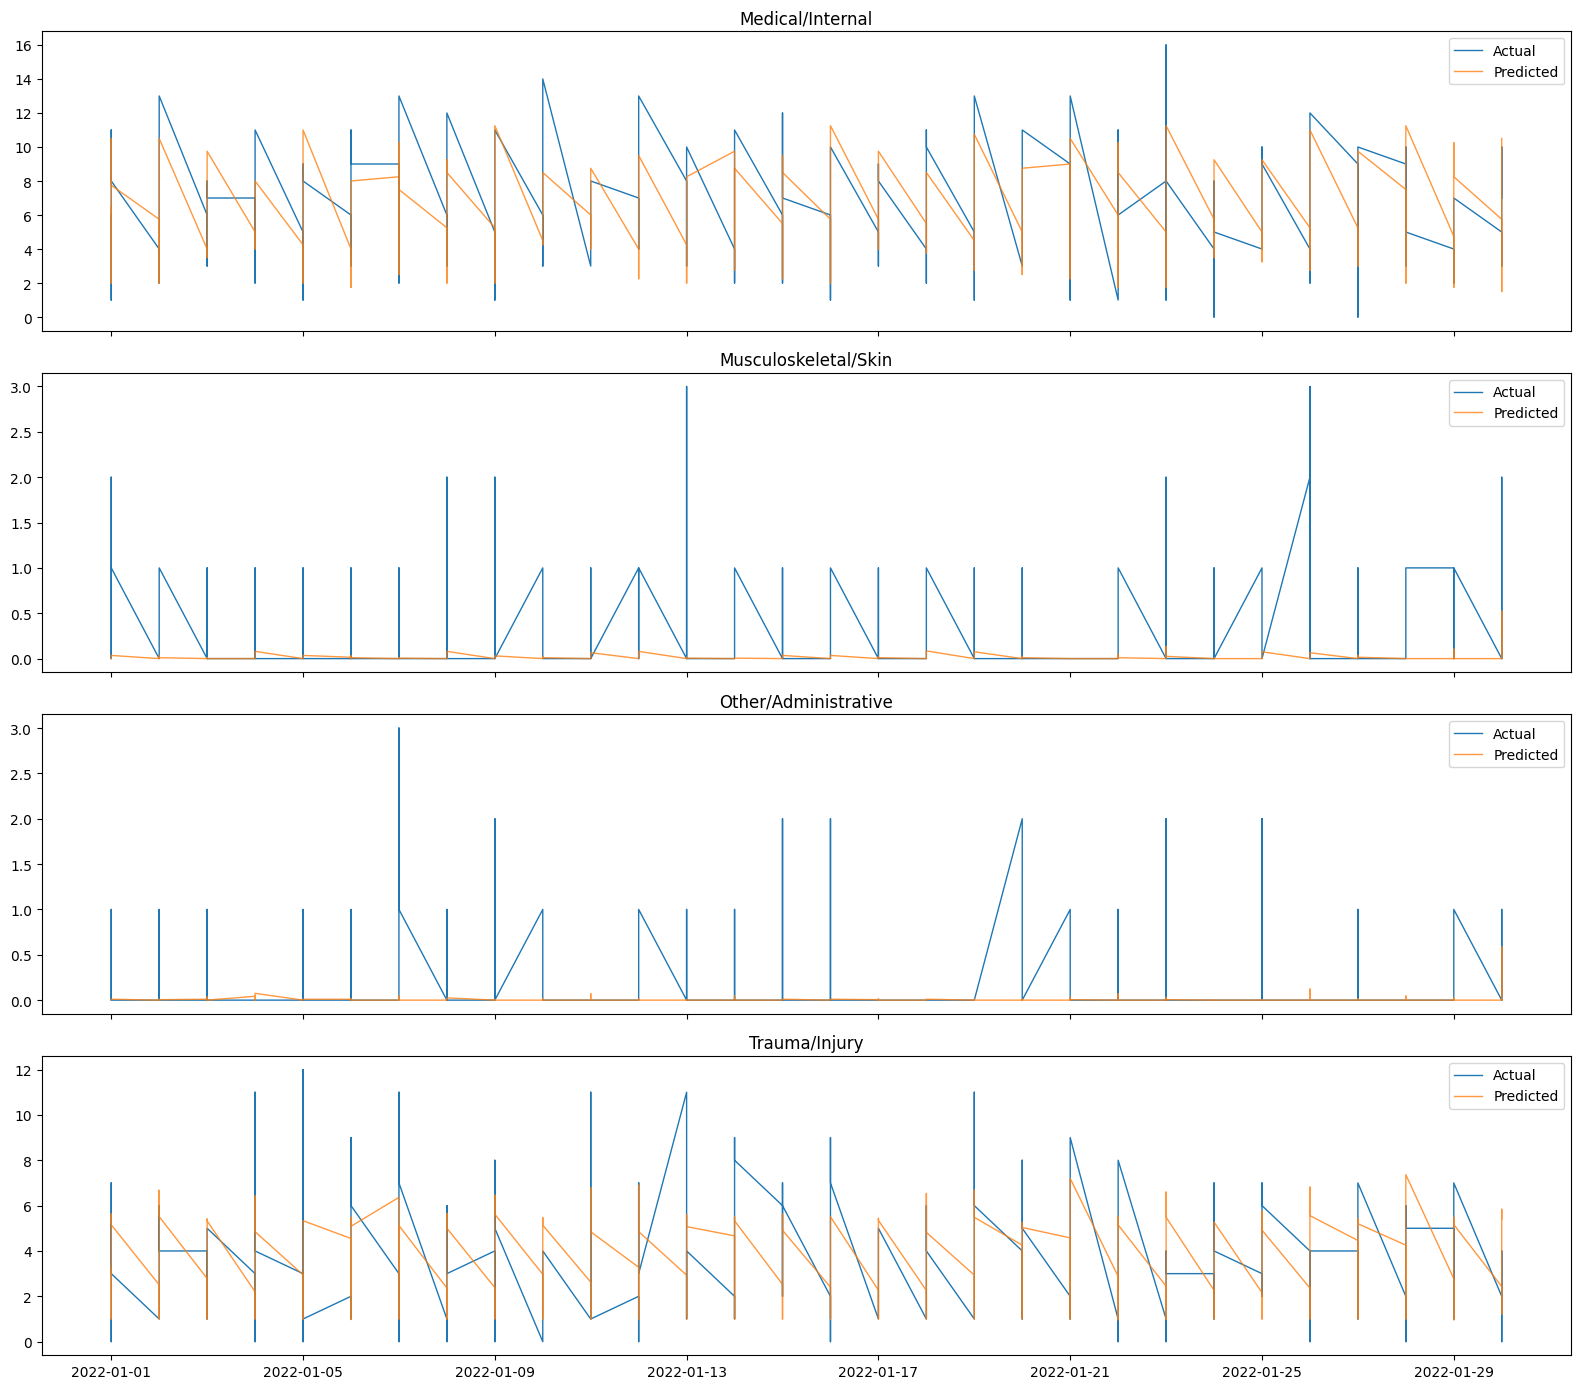

In [ ]:
test_predictions = {}
for cat in categories:
    if cat in final_models:
        y_pred_cat = final_models[cat].predict(test_df[all_features])
    else:
        y_pred_cat = test_df[f'lag_4wk_{cat}']
    test_predictions[cat] = y_pred_cat

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

for i, cat in enumerate(categories):
    actual_vals = test_df[cat].values[:180]
    pred_vals = test_predictions[cat].values[:180] if hasattr(test_predictions[cat], 'values') else test_predictions[cat][:180]
    axes[i].plot(test_df['date'].values[:180], actual_vals, label='Actual', linewidth=1)
    axes[i].plot(test_df['date'].values[:180], pred_vals, label='Predicted', linewidth=1, alpha=0.8)
    axes[i].set_title(cat)
    axes[i].legend()

plt.tight_layout()
plt.savefig('patient_type_actual_vs_predicted.png', dpi=300)
plt.show()

In [ ]:
features['day_of_month'] = pd.to_datetime(features['date']).dt.day

train_clean = features[features['year'] <= 2019].dropna(subset=['lag_4wk_avg'])
test_clean2 = features[features['year'] == 2022]

feature_cols_dom = ['hour_slot', 'lag_4wk_avg', 'day_of_month']

X_train = train_clean[feature_cols_dom]
y_train = train_clean['patient_count']
X_test = test_clean2[feature_cols_dom]
y_test = test_clean2['patient_count']

sample_weights = 1 / np.sqrt(y_train + 1)

model_dom = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
model_dom.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_dom = model_dom.predict(X_test)

mae_dom = mean_absolute_error(y_test, y_pred_dom)
rmse_dom = np.sqrt(mean_squared_error(y_test, y_pred_dom))
mape_dom = np.mean(np.abs((y_test - y_pred_dom) / y_test)) * 100

print(f'With day_of_month — MAE: {mae_dom:.2f}, RMSE: {rmse_dom:.2f}, MAPE: {mape_dom:.2f}%')

With day_of_month — MAE: 2.88, RMSE: 3.75, MAPE: 32.76%


In [ ]:
feature_cols_dow = ['hour_slot', 'lag_4wk_avg', 'day_of_week']

X_train = train_clean[feature_cols_dow]
X_test = test_clean2[feature_cols_dow]

model_dow = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
model_dow.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_dow = model_dow.predict(X_test)

mae_dow = mean_absolute_error(y_test, y_pred_dow)
rmse_dow = np.sqrt(mean_squared_error(y_test, y_pred_dow))
mape_dow = np.mean(np.abs((y_test - y_pred_dow) / y_test)) * 100

print(f'With day_of_week — MAE: {mae_dow:.2f}, RMSE: {rmse_dow:.2f}, MAPE: {mape_dow:.2f}%')

With day_of_week — MAE: 2.88, RMSE: 3.76, MAPE: 32.73%


In [ ]:
feature_cols_3 = ['hour_slot', 'lag_4wk_avg', 'month', 'day_of_week', 'week_of_year']

X_train = train_clean[feature_cols_3]
X_test = test_clean2[feature_cols_3]

model_3feat = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
model_3feat.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_3feat = model_3feat.predict(X_test)

mae_3 = mean_absolute_error(y_test, y_pred_3feat)
rmse_3 = np.sqrt(mean_squared_error(y_test, y_pred_3feat))
mape_3 = np.mean(np.abs((y_test - y_pred_3feat) / y_test)) * 100

print(f'With month+day_of_week+week_of_year — MAE: {mae_3:.2f}, RMSE: {rmse_3:.2f}, MAPE: {mape_3:.2f}%')

With month+day_of_week+week_of_year — MAE: 2.87, RMSE: 3.74, MAPE: 32.03%


In [ ]:
mae_peak_3feat = mean_absolute_error(y_test[peak_mask], y_pred_3feat[peak_mask])
print(f'Peak MAE with 3 extra features: {mae_peak_3feat:.2f}')

Peak MAE with 3 extra features: 5.46


In [ ]:
daily_2020 = features[(features['year']==2020) & (features['month'].isin([1,2,3]))].groupby('date')['patient_count'].sum()
print(daily_2020)

date
2020-01-01    89
2020-01-02    90
2020-01-03    93
2020-01-04    91
2020-01-05    86
              ..
2020-03-27    50
2020-03-28    42
2020-03-29    53
2020-03-30    62
2020-03-31    50
Name: patient_count, Length: 89, dtype: int64


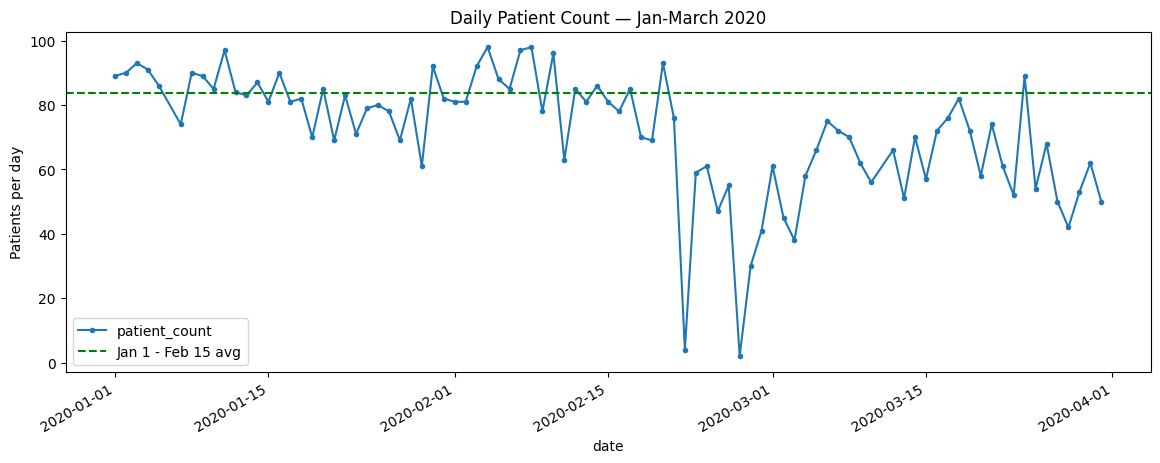

In [ ]:
import matplotlib.pyplot as plt

daily_2020.plot(figsize=(14,5), marker='o', markersize=3)
plt.axhline(y=daily_2020[:'2020-02-15'].mean(), color='green', linestyle='--', label='Jan 1 - Feb 15 avg')
plt.title('Daily Patient Count — Jan-March 2020')
plt.ylabel('Patients per day')
plt.legend()
plt.show()

In [ ]:
daily_2020.sort_values().head(10)

,patient_count
date,
2020-02-27,2
2020-02-22,4
2020-02-28,30
2020-03-03,38
2020-02-29,41
2020-03-28,42
2020-03-02,45
2020-02-25,47
2020-03-27,50


In [ ]:
feb_2020 = features[(features['year']==2020) & (features['month']==2)][['date','patient_count']].groupby('date')['patient_count'].sum()
print(feb_2020)

date
2020-02-01    81
2020-02-02    81
2020-02-03    92
2020-02-04    98
2020-02-05    88
2020-02-06    85
2020-02-07    97
2020-02-08    98
2020-02-09    78
2020-02-10    96
2020-02-11    63
2020-02-12    85
2020-02-13    81
2020-02-14    86
2020-02-15    81
2020-02-16    78
2020-02-17    85
2020-02-18    70
2020-02-19    69
2020-02-20    93
2020-02-21    76
2020-02-22     4
2020-02-23    59
2020-02-24    61
2020-02-25    47
2020-02-26    55
2020-02-27     2
2020-02-28    30
2020-02-29    41
Name: patient_count, dtype: int64


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Filter to the clean, continuous range only
clean_features = features[features['date'] <= '2020-02-21'].copy()
clean_features = clean_features.sort_values(['date', 'hour_slot']).reset_index(drop=True)

# 2. Rebuild lag_4wk_avg on this continuous range (no gap now)
clean_features['lag_4wk_avg'] = (
    clean_features.groupby(['day_of_week', 'hour_slot'])['patient_count']
    .transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
)

clean_features = clean_features.dropna(subset=['lag_4wk_avg'])

# 3. Chronological 80/20 split — NOT random, respects time order
split_idx = int(len(clean_features) * 0.8)
train_new = clean_features.iloc[:split_idx]
test_new = clean_features.iloc[split_idx:]

print(f'Train: {len(train_new)} rows, {train_new["date"].min()} to {train_new["date"].max()}')
print(f'Test: {len(test_new)} rows, {test_new["date"].min()} to {test_new["date"].max()}')

# 4. Train — same final architecture as before
feature_cols = ['hour_slot', 'lag_4wk_avg']
X_train = train_new[feature_cols]
y_train = train_new['patient_count']
X_test = test_new[feature_cols]
y_test = test_new['patient_count']

model_new = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
model_new.fit(X_train, y_train)
y_pred_new = model_new.predict(X_test)

# 5. Evaluate
mae_new = mean_absolute_error(y_test, y_pred_new)
rmse_new = np.sqrt(mean_squared_error(y_test, y_pred_new))
mape_new = np.mean(np.abs((y_test - y_pred_new) / y_test)) * 100
wape_new = np.sum(np.abs(y_test - y_pred_new)) / np.sum(y_test) * 100

threshold_new = y_test.quantile(0.9)
peak_mask_new = y_test >= threshold_new
peak_mae_new = mean_absolute_error(y_test[peak_mask_new], y_pred_new[peak_mask_new])

print(f'\nNew split — MAE: {mae_new:.2f}, RMSE: {rmse_new:.2f}, MAPE: {mape_new:.2f}%, WAPE: {wape_new:.2f}%, Peak MAE: {peak_mae_new:.2f}')

# 6. Naive baseline on the same new split, for fair comparison
naive_pred_new = test_new['lag_4wk_avg']
naive_mae_new = mean_absolute_error(y_test, naive_pred_new)
naive_rmse_new = np.sqrt(mean_squared_error(y_test, naive_pred_new))
naive_mape_new = np.mean(np.abs((y_test - naive_pred_new) / y_test)) * 100

print(f'Naive (new split) — MAE: {naive_mae_new:.2f}, RMSE: {naive_rmse_new:.2f}, MAPE: {naive_mape_new:.2f}%')

Train: 5060 rows, 2017-03-28 00:00:00 to 2019-07-23 00:00:00
Test: 1265 rows, 2019-07-23 00:00:00 to 2020-02-21 00:00:00

New split — MAE: 3.14, RMSE: 4.02, MAPE: 29.81%, WAPE: 20.97%, Peak MAE: 6.87
Naive (new split) — MAE: 3.29, RMSE: 4.19, MAPE: 31.83%


In [ ]:
import xgboost as xgb

model_xgb_new = xgb.XGBRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42
)
model_xgb_new.fit(X_train, y_train)
y_pred_xgb_new = model_xgb_new.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb_new)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb_new))
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb_new) / y_test)) * 100
wape_xgb = np.sum(np.abs(y_test - y_pred_xgb_new)) / np.sum(y_test) * 100

peak_mae_xgb = mean_absolute_error(y_test[peak_mask_new], y_pred_xgb_new[peak_mask_new])

print(f'XGBoost (new split) — MAE: {mae_xgb:.2f}, RMSE: {rmse_xgb:.2f}, MAPE: {mape_xgb:.2f}%, WAPE: {wape_xgb:.2f}%, Peak MAE: {peak_mae_xgb:.2f}')

XGBoost (new split) — MAE: 3.18, RMSE: 4.08, MAPE: 31.05%, WAPE: 21.22%, Peak MAE: 6.75


In [ ]:
feature_cols_cal = ['hour_slot', 'lag_4wk_avg', 'day_of_week', 'month']

X_train_cal = train_new[feature_cols_cal]
X_test_cal = test_new[feature_cols_cal]

model_cal = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
model_cal.fit(X_train_cal, y_train)
y_pred_cal = model_cal.predict(X_test_cal)

mae_cal = mean_absolute_error(y_test, y_pred_cal)
rmse_cal = np.sqrt(mean_squared_error(y_test, y_pred_cal))
mape_cal = np.mean(np.abs((y_test - y_pred_cal) / y_test)) * 100
wape_cal = np.sum(np.abs(y_test - y_pred_cal)) / np.sum(y_test) * 100
peak_mae_cal = mean_absolute_error(y_test[peak_mask_new], y_pred_cal[peak_mask_new])

print(f'+day_of_week+month — MAE: {mae_cal:.2f}, RMSE: {rmse_cal:.2f}, MAPE: {mape_cal:.2f}%, WAPE: {wape_cal:.2f}%, Peak MAE: {peak_mae_cal:.2f}')

+day_of_week+month — MAE: 3.16, RMSE: 4.05, MAPE: 29.50%, WAPE: 21.09%, Peak MAE: 7.07


In [ ]:
feature_cols_3feat = ['hour_slot', 'lag_4wk_avg', 'month', 'day_of_week', 'week_of_year']

X_train_3 = train_new[feature_cols_3feat]
X_test_3 = test_new[feature_cols_3feat]

model_3feat_new = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
model_3feat_new.fit(X_train_3, y_train)
y_pred_3feat_new = model_3feat_new.predict(X_test_3)

mae_3f = mean_absolute_error(y_test, y_pred_3feat_new)
rmse_3f = np.sqrt(mean_squared_error(y_test, y_pred_3feat_new))
mape_3f = np.mean(np.abs((y_test - y_pred_3feat_new) / y_test)) * 100
wape_3f = np.sum(np.abs(y_test - y_pred_3feat_new)) / np.sum(y_test) * 100
peak_mae_3f = mean_absolute_error(y_test[peak_mask_new], y_pred_3feat_new[peak_mask_new])

print(f'+month+day_of_week+week_of_year — MAE: {mae_3f:.2f}, RMSE: {rmse_3f:.2f}, MAPE: {mape_3f:.2f}%, WAPE: {wape_3f:.2f}%, Peak MAE: {peak_mae_3f:.2f}')

+month+day_of_week+week_of_year — MAE: 3.17, RMSE: 4.06, MAPE: 29.46%, WAPE: 21.16%, Peak MAE: 7.13


In [ ]:
import lightgbm as lgb

model_lgbm = lgb.LGBMRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, verbose=-1
)
model_lgbm.fit(X_train, y_train)
y_pred_lgbm = model_lgbm.predict(X_test)

mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
mape_lgbm = np.mean(np.abs((y_test - y_pred_lgbm) / y_test)) * 100
wape_lgbm = np.sum(np.abs(y_test - y_pred_lgbm)) / np.sum(y_test) * 100
peak_mae_lgbm = mean_absolute_error(y_test[peak_mask_new], y_pred_lgbm[peak_mask_new])

print(f'LightGBM — MAE: {mae_lgbm:.2f}, RMSE: {rmse_lgbm:.2f}, MAPE: {mape_lgbm:.2f}%, WAPE: {wape_lgbm:.2f}%, Peak MAE: {peak_mae_lgbm:.2f}')

LightGBM — MAE: 3.15, RMSE: 4.02, MAPE: 30.77%, WAPE: 20.99%, Peak MAE: 6.60


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_lgbm = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.03, 0.05, 0.1],
    'num_leaves': [15, 31, 63]
}

grid_lgbm = GridSearchCV(
    lgb.LGBMRegressor(random_state=42, verbose=-1),
    param_grid_lgbm,
    scoring='neg_mean_absolute_error',
    cv=5
)
grid_lgbm.fit(X_train, y_train)

print('Best params:', grid_lgbm.best_params_)

best_lgbm = grid_lgbm.best_estimator_
y_pred_best_lgbm = best_lgbm.predict(X_test)

mae_best_lgbm = mean_absolute_error(y_test, y_pred_best_lgbm)
rmse_best_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_best_lgbm))
mape_best_lgbm = np.mean(np.abs((y_test - y_pred_best_lgbm) / y_test)) * 100
wape_best_lgbm = np.sum(np.abs(y_test - y_pred_best_lgbm)) / np.sum(y_test) * 100
peak_mae_best_lgbm = mean_absolute_error(y_test[peak_mask_new], y_pred_best_lgbm[peak_mask_new])

print(f'Tuned LightGBM — MAE: {mae_best_lgbm:.2f}, RMSE: {rmse_best_lgbm:.2f}, MAPE: {mape_best_lgbm:.2f}%, WAPE: {wape_best_lgbm:.2f}%, Peak MAE: {peak_mae_best_lgbm:.2f}')

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'num_leaves': 15}
Tuned LightGBM — MAE: 3.12, RMSE: 3.98, MAPE: 30.86%, WAPE: 20.80%, Peak MAE: 6.61


In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor

models_to_test = {
    'ElasticNet (linear)': ElasticNet(random_state=42),
    'SVR': SVR(),
    'Neural Network (MLP)': MLPRegressor(hidden_layer_sizes=(50,), max_iter=1000, random_state=42),
    'KNN': KNeighborsRegressor(n_neighbors=5),
}

# CatBoost needs installing first
try:
    from catboost import CatBoostRegressor
    models_to_test['CatBoost'] = CatBoostRegressor(iterations=200, depth=6, learning_rate=0.05, random_state=42, verbose=False)
except ImportError:
    print("CatBoost not installed — run !pip install catboost --quiet first, then re-run this cell")

results_table = []

for name, model in models_to_test.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    wape = np.sum(np.abs(y_test - y_pred)) / np.sum(y_test) * 100
    peak_mae = mean_absolute_error(y_test[peak_mask_new], y_pred[peak_mask_new])

    results_table.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'WAPE': wape, 'Peak MAE': peak_mae})

results_df = pd.DataFrame(results_table)
print(results_df.to_string(index=False))

CatBoost not installed — run !pip install catboost --quiet first, then re-run this cell
               Model      MAE     RMSE      MAPE      WAPE  Peak MAE
 ElasticNet (linear) 3.270390 4.123502 35.754931 21.830213  6.134115
                 SVR 3.166236 4.050475 30.629513 21.134974  7.022139
Neural Network (MLP) 3.204616 4.069478 33.689853 21.391163  5.911086
                 KNN 3.425929 4.343609 34.590076 22.868450  5.842105


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [ ]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 10, 15],
    'weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(KNeighborsRegressor(), param_grid_knn, scoring='neg_mean_absolute_error', cv=5)
grid_knn.fit(X_train, y_train)

print('Best KNN params:', grid_knn.best_params_)

best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)

mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mape_knn = np.mean(np.abs((y_test - y_pred_knn) / y_test)) * 100
wape_knn = np.sum(np.abs(y_test - y_pred_knn)) / np.sum(y_test) * 100
peak_mae_knn = mean_absolute_error(y_test[peak_mask_new], y_pred_knn[peak_mask_new])

print(f'Tuned KNN — MAE: {mae_knn:.2f}, RMSE: {rmse_knn:.2f}, MAPE: {mape_knn:.2f}%, WAPE: {wape_knn:.2f}%, Peak MAE: {peak_mae_knn:.2f}')

Best KNN params: {'n_neighbors': 15, 'weights': 'uniform'}
Tuned KNN — MAE: 3.21, RMSE: 4.09, MAPE: 32.23%, WAPE: 21.43%, Peak MAE: 6.46


In [ ]:
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50,50)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

grid_mlp = GridSearchCV(
    MLPRegressor(max_iter=2000, random_state=42),
    param_grid_mlp,
    scoring='neg_mean_absolute_error',
    cv=5
)
grid_mlp.fit(X_train, y_train)

print('Best MLP params:', grid_mlp.best_params_)

best_mlp = grid_mlp.best_estimator_
y_pred_mlp = best_mlp.predict(X_test)

mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
mape_mlp = np.mean(np.abs((y_test - y_pred_mlp) / y_test)) * 100
wape_mlp = np.sum(np.abs(y_test - y_pred_mlp)) / np.sum(y_test) * 100
peak_mae_mlp = mean_absolute_error(y_test[peak_mask_new], y_pred_mlp[peak_mask_new])

print(f'Tuned MLP — MAE: {mae_mlp:.2f}, RMSE: {rmse_mlp:.2f}, MAPE: {mape_mlp:.2f}%, WAPE: {wape_mlp:.2f}%, Peak MAE: {peak_mae_mlp:.2f}')

Best MLP params: {'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.01}
Tuned MLP — MAE: 3.13, RMSE: 3.98, MAPE: 32.69%, WAPE: 20.92%, Peak MAE: 5.43


In [ ]:
import statsmodels.api as sm

# Build one continuous, ordered sequence of patient counts
ts_data = clean_features.sort_values(['date','hour_slot']).reset_index(drop=True)
y_full = ts_data['patient_count'].values

split_idx = int(len(ts_data) * 0.8)
y_train_ts = y_full[:split_idx]
y_test_ts = y_full[split_idx:]

# seasonal_order's last number (6) tells it "the pattern repeats every 6 steps" — one full day
model_sarimax = sm.tsa.statespace.SARIMAX(
    y_train_ts,
    order=(1,0,1),
    seasonal_order=(1,0,1,6),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit_sarimax = model_sarimax.fit(disp=False)

forecast = fit_sarimax.forecast(steps=len(y_test_ts))

mae_sarimax = mean_absolute_error(y_test_ts, forecast)
rmse_sarimax = np.sqrt(mean_squared_error(y_test_ts, forecast))
mape_sarimax = np.mean(np.abs((y_test_ts - forecast) / y_test_ts)) * 100
wape_sarimax = np.sum(np.abs(y_test_ts - forecast)) / np.sum(y_test_ts) * 100

peak_threshold_ts = np.quantile(y_test_ts, 0.9)
peak_mask_ts = y_test_ts >= peak_threshold_ts
peak_mae_sarimax = mean_absolute_error(y_test_ts[peak_mask_ts], forecast[peak_mask_ts])

print(f'SARIMAX — MAE: {mae_sarimax:.2f}, RMSE: {rmse_sarimax:.2f}, MAPE: {mape_sarimax:.2f}%, WAPE: {wape_sarimax:.2f}%, Peak MAE: {peak_mae_sarimax:.2f}')

SARIMAX — MAE: 7.09, RMSE: 8.93, MAPE: 78.96%, WAPE: 47.31%, Peak MAE: 14.16


In [ ]:
# Build raw sequential lags — the actual previous 6 slot values (last full day)
clean_features_sorted = clean_features.sort_values(['date','hour_slot']).reset_index(drop=True)

for i in range(1, 7):
    clean_features_sorted[f'raw_lag_{i}'] = clean_features_sorted['patient_count'].shift(i)

nnar_data = clean_features_sorted.dropna(subset=[f'raw_lag_{i}' for i in range(1,7)])

split_idx_nnar = int(len(nnar_data) * 0.8)
train_nnar = nnar_data.iloc[:split_idx_nnar]
test_nnar = nnar_data.iloc[split_idx_nnar:]

lag_cols = [f'raw_lag_{i}' for i in range(1,7)]
X_train_nnar = train_nnar[lag_cols]
y_train_nnar = train_nnar['patient_count']
X_test_nnar = test_nnar[lag_cols]
y_test_nnar = test_nnar['patient_count']

model_nnar = MLPRegressor(hidden_layer_sizes=(50,), max_iter=2000, random_state=42)
model_nnar.fit(X_train_nnar, y_train_nnar)
y_pred_nnar = model_nnar.predict(X_test_nnar)

mae_nnar = mean_absolute_error(y_test_nnar, y_pred_nnar)
rmse_nnar = np.sqrt(mean_squared_error(y_test_nnar, y_pred_nnar))
mape_nnar = np.mean(np.abs((y_test_nnar - y_pred_nnar) / y_test_nnar)) * 100
wape_nnar = np.sum(np.abs(y_test_nnar - y_pred_nnar)) / np.sum(y_test_nnar) * 100

peak_threshold_nnar = y_test_nnar.quantile(0.9)
peak_mask_nnar = y_test_nnar >= peak_threshold_nnar
peak_mae_nnar = mean_absolute_error(y_test_nnar[peak_mask_nnar], y_pred_nnar[peak_mask_nnar])

print(f'NNAR-style MLP — MAE: {mae_nnar:.2f}, RMSE: {rmse_nnar:.2f}, MAPE: {mape_nnar:.2f}%, WAPE: {wape_nnar:.2f}%, Peak MAE: {peak_mae_nnar:.2f}')

NNAR-style MLP — MAE: 3.49, RMSE: 4.45, MAPE: 37.30%, WAPE: 23.31%, Peak MAE: 6.68


In [ ]:
%whos ndarray

Variable            Type       Data/Info
----------------------------------------
actual_vals         ndarray    180: 180 elems, type `int64`, 1440 bytes
axes                ndarray    4: 4 elems, type `object`, 32 bytes
forecast            ndarray    1265: 1265 elems, type `float64`, 10120 bytes
peak_mask_ts        ndarray    1265: 1265 elems, type `bool`, 1265 bytes
pred_vals           ndarray    180: 180 elems, type `float64`, 1440 bytes
y_full              ndarray    6325: 6325 elems, type `int64`, 50600 bytes
y_pred              ndarray    1265: 1265 elems, type `float64`, 10120 bytes
y_pred_3feat        ndarray    474: 474 elems, type `float64`, 3792 bytes
y_pred_3feat_new    ndarray    1265: 1265 elems, type `float64`, 10120 bytes
y_pred_best         ndarray    474: 474 elems, type `float32`, 1896 bytes
y_pred_best_lgbm    ndarray    1265: 1265 elems, type `float64`, 10120 bytes
y_pred_c            ndarray    474: 474 elems, type `float32`, 1896 bytes
y_pred_cal          ndarray

In [ ]:
mae_check = mean_absolute_error(y_test, y_pred_mlp)
print(f'y_pred_mlp MAE: {mae_check:.2f}')

y_pred_mlp MAE: 3.13


In [ ]:
y_pred_blend = (y_pred_new + y_pred_mlp) / 2

mae_blend = mean_absolute_error(y_test, y_pred_blend)
rmse_blend = np.sqrt(mean_squared_error(y_test, y_pred_blend))
mape_blend = np.mean(np.abs((y_test - y_pred_blend) / y_test)) * 100
wape_blend = np.sum(np.abs(y_test - y_pred_blend)) / np.sum(y_test) * 100
peak_mae_blend = mean_absolute_error(y_test[peak_mask_new], y_pred_blend[peak_mask_new])

print(f'Blended (RF+MLP) — MAE: {mae_blend:.2f}, RMSE: {rmse_blend:.2f}, MAPE: {mape_blend:.2f}%, WAPE: {wape_blend:.2f}%, Peak MAE: {peak_mae_blend:.2f}')

Blended (RF+MLP) — MAE: 3.10, RMSE: 3.96, MAPE: 30.95%, WAPE: 20.70%, Peak MAE: 6.14


In [ ]:
from sklearn.linear_model import Ridge

model_ridge = Ridge(alpha=1.0, random_state=42)
model_ridge.fit(X_train, y_train)
y_pred_ridge = model_ridge.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mape_ridge = np.mean(np.abs((y_test - y_pred_ridge) / y_test)) * 100
wape_ridge = np.sum(np.abs(y_test - y_pred_ridge)) / np.sum(y_test) * 100
peak_mae_ridge = mean_absolute_error(y_test[peak_mask_new], y_pred_ridge[peak_mask_new])

print(f'Ridge — MAE: {mae_ridge:.2f}, RMSE: {rmse_ridge:.2f}, MAPE: {mape_ridge:.2f}%, WAPE: {wape_ridge:.2f}%, Peak MAE: {peak_mae_ridge:.2f}')

Ridge — MAE: 3.26, RMSE: 4.10, MAPE: 35.26%, WAPE: 21.73%, Peak MAE: 5.87


In [ ]:
y_pred_ridge_full = model_ridge.predict(X_test)
y_pred_3way = (y_pred_new + y_pred_mlp + y_pred_ridge_full) / 3

mae_3way = mean_absolute_error(y_test, y_pred_3way)
rmse_3way = np.sqrt(mean_squared_error(y_test, y_pred_3way))
mape_3way = np.mean(np.abs((y_test - y_pred_3way) / y_test)) * 100
wape_3way = np.sum(np.abs(y_test - y_pred_3way)) / np.sum(y_test) * 100
peak_mae_3way = mean_absolute_error(y_test[peak_mask_new], y_pred_3way[peak_mask_new])

print(f'3-way blend (RF+MLP+Ridge) — MAE: {mae_3way:.2f}, RMSE: {rmse_3way:.2f}, MAPE: {mape_3way:.2f}%, WAPE: {wape_3way:.2f}%, Peak MAE: {peak_mae_3way:.2f}')

3-way blend (RF+MLP+Ridge) — MAE: 3.13, RMSE: 3.98, MAPE: 32.08%, WAPE: 20.87%, Peak MAE: 6.01


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# Build sequences: use the last 24 slots (4 days) to predict the next one
sequence_length = 24

def make_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

full_series = clean_features.sort_values(['date','hour_slot'])['patient_count'].values
split_point = int(len(full_series) * 0.8)

train_series = full_series[:split_point]
test_series = full_series[split_point - sequence_length:]  # need lookback for first test predictions

X_train_seq, y_train_seq = make_sequences(train_series, sequence_length)
X_test_seq, y_test_seq = make_sequences(test_series, sequence_length)

X_train_seq = X_train_seq.reshape(-1, sequence_length, 1)
X_test_seq = X_test_seq.reshape(-1, sequence_length, 1)

# Simple LSTM
model_lstm = tf.keras.Sequential([
    layers.LSTM(32, input_shape=(sequence_length, 1)),
    layers.Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mae')
model_lstm.fit(X_train_seq, y_train_seq, epochs=30, batch_size=32, verbose=0)

y_pred_lstm = model_lstm.predict(X_test_seq).flatten()

mae_lstm = mean_absolute_error(y_test_seq, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm))
mape_lstm = np.mean(np.abs((y_test_seq - y_pred_lstm) / y_test_seq)) * 100
wape_lstm = np.sum(np.abs(y_test_seq - y_pred_lstm)) / np.sum(y_test_seq) * 100

peak_threshold_lstm = np.quantile(y_test_seq, 0.9)
peak_mask_lstm = y_test_seq >= peak_threshold_lstm
peak_mae_lstm = mean_absolute_error(y_test_seq[peak_mask_lstm], y_pred_lstm[peak_mask_lstm])

print(f'LSTM — MAE: {mae_lstm:.2f}, RMSE: {rmse_lstm:.2f}, MAPE: {mape_lstm:.2f}%, WAPE: {wape_lstm:.2f}%, Peak MAE: {peak_mae_lstm:.2f}')

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
LSTM — MAE: 3.39, RMSE: 4.38, MAPE: 32.22%, WAPE: 22.65%, Peak MAE: 7.83


In [ ]:
np.random.seed(42)
y_train_shuffled = np.random.permutation(y_train)

model_shuffled = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
model_shuffled.fit(X_train, y_train_shuffled)
y_pred_shuffled = model_shuffled.predict(X_test)

mae_shuffled = mean_absolute_error(y_test, y_pred_shuffled)
print(f'Shuffled-target MAE: {mae_shuffled:.2f} (compare to real MAE: 3.14)')

Shuffled-target MAE: 5.71 (compare to real MAE: 3.14)


In [ ]:
split_idx_73 = int(len(clean_features) * 0.7)
train_73 = clean_features.iloc[:split_idx_73]
test_73 = clean_features.iloc[split_idx_73:]

print(f'Train: {len(train_73)} rows, {train_73["date"].min()} to {train_73["date"].max()}')
print(f'Test: {len(test_73)} rows, {test_73["date"].min()} to {test_73["date"].max()}')

X_train_73 = train_73[feature_cols]
y_train_73 = train_73['patient_count']
X_test_73 = test_73[feature_cols]
y_test_73 = test_73['patient_count']

rf_73 = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
rf_73.fit(X_train_73, y_train_73)
y_pred_rf_73 = rf_73.predict(X_test_73)

mlp_73 = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=2000, random_state=42)
mlp_73.fit(X_train_73, y_train_73)
y_pred_mlp_73 = mlp_73.predict(X_test_73)

y_pred_blend_73 = (y_pred_rf_73 + y_pred_mlp_73) / 2

mae_73 = mean_absolute_error(y_test_73, y_pred_blend_73)
rmse_73 = np.sqrt(mean_squared_error(y_test_73, y_pred_blend_73))
mape_73 = np.mean(np.abs((y_test_73 - y_pred_blend_73) / y_test_73)) * 100
wape_73 = np.sum(np.abs(y_test_73 - y_pred_blend_73)) / np.sum(y_test_73) * 100

peak_threshold_73 = y_test_73.quantile(0.9)
peak_mask_73 = y_test_73 >= peak_threshold_73
peak_mae_73 = mean_absolute_error(y_test_73[peak_mask_73], y_pred_blend_73[peak_mask_73])

print(f'70/30 blend — MAE: {mae_73:.2f}, RMSE: {rmse_73:.2f}, MAPE: {mape_73:.2f}%, WAPE: {wape_73:.2f}%, Peak MAE: {peak_mae_73:.2f}')

Train: 4427 rows, 2017-03-28 00:00:00 to 2019-04-07 00:00:00
Test: 1898 rows, 2019-04-08 00:00:00 to 2020-02-21 00:00:00
70/30 blend — MAE: 3.16, RMSE: 4.06, MAPE: 30.46%, WAPE: 21.05%, Peak MAE: 6.85


In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

fold_results = []

for fold_num, (train_idx, test_idx) in enumerate(tscv.split(clean_features), 1):
    train_fold = clean_features.iloc[train_idx]
    test_fold = clean_features.iloc[test_idx]

    X_train_fold = train_fold[feature_cols]
    y_train_fold = train_fold['patient_count']
    X_test_fold = test_fold[feature_cols]
    y_test_fold = test_fold['patient_count']

    rf_fold = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
    rf_fold.fit(X_train_fold, y_train_fold)

    mlp_fold = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=2000, random_state=42)
    mlp_fold.fit(X_train_fold, y_train_fold)

    y_pred_fold = (rf_fold.predict(X_test_fold) + mlp_fold.predict(X_test_fold)) / 2

    mae_fold = mean_absolute_error(y_test_fold, y_pred_fold)
    fold_results.append(mae_fold)
    print(f'Fold {fold_num}: MAE = {mae_fold:.2f} (train size: {len(train_fold)}, test size: {len(test_fold)})')

print(f'\nAverage MAE across 5 folds: {np.mean(fold_results):.2f}')
print(f'Standard deviation: {np.std(fold_results):.2f}')

Fold 1: MAE = 3.49 (train size: 1055, test size: 1054)
Fold 2: MAE = 3.22 (train size: 2109, test size: 1054)
Fold 3: MAE = 3.25 (train size: 3163, test size: 1054)
Fold 4: MAE = 3.41 (train size: 4217, test size: 1054)
Fold 5: MAE = 3.06 (train size: 5271, test size: 1054)

Average MAE across 5 folds: 3.29
Standard deviation: 0.15


In [ ]:
def walk_forward_evaluate(data, feature_cols, target_col, initial_train_frac=0.8, step_size=42):
    data = data.sort_values(['date', 'hour_slot']).reset_index(drop=True)
    n = len(data)
    train_end = int(n * initial_train_frac)

    all_actuals = []
    all_preds = []

    current_train_end = train_end
    while current_train_end < n:
        # Train on everything real up to this point
        train_data = data.iloc[:current_train_end]
        step_end = min(current_train_end + step_size, n)
        test_step = data.iloc[current_train_end:step_end]

        X_train_wf = train_data[feature_cols]
        y_train_wf = train_data[target_col]
        X_test_wf = test_step[feature_cols]
        y_test_wf = test_step[target_col]

        # Fresh model, retrained each time
        model_wf = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
        model_wf.fit(X_train_wf, y_train_wf)
        preds = model_wf.predict(X_test_wf)

        all_actuals.extend(y_test_wf.values)
        all_preds.extend(preds)

        # Move the window forward using REAL values only — never the model's own predictions
        current_train_end = step_end

    all_actuals = np.array(all_actuals)
    all_preds = np.array(all_preds)

    mae_wf = mean_absolute_error(all_actuals, all_preds)
    rmse_wf = np.sqrt(mean_squared_error(all_actuals, all_preds))
    mape_wf = np.mean(np.abs((all_actuals - all_preds) / all_actuals)) * 100
    wape_wf = np.sum(np.abs(all_actuals - all_preds)) / np.sum(all_actuals) * 100

    print(f'Walk-forward — MAE: {mae_wf:.2f}, RMSE: {rmse_wf:.2f}, MAPE: {mape_wf:.2f}%, WAPE: {wape_wf:.2f}%')
    return all_actuals, all_preds

# Run it — step_size=42 means retrain every week (7 days x 6 slots)
actuals_wf, preds_wf = walk_forward_evaluate(clean_features, feature_cols, 'patient_count', initial_train_frac=0.8, step_size=42)

Walk-forward — MAE: 3.13, RMSE: 4.00, MAPE: 29.99%, WAPE: 20.91%


In [ ]:
# Naive baseline using just the SINGLE most recent same-day+slot value (no averaging)
naive_single = clean_features.groupby(['day_of_week','hour_slot'])['patient_count'].shift(1)

test_naive_single = naive_single.loc[test_new.index]
mae_naive_single = mean_absolute_error(y_test, test_naive_single)
rmse_naive_single = np.sqrt(mean_squared_error(y_test, test_naive_single))
mape_naive_single = np.mean(np.abs((y_test - test_naive_single) / y_test)) * 100

print(f'Naive (single last value) — MAE: {mae_naive_single:.2f}, RMSE: {rmse_naive_single:.2f}, MAPE: {mape_naive_single:.2f}%')

Naive (single last value) — MAE: 4.22, RMSE: 5.33, MAPE: 39.50%


In [ ]:
expanding_avg = (
    clean_features.groupby(['day_of_week','hour_slot'])['patient_count']
    .transform(lambda x: x.shift(1).expanding().mean())
)

test_expanding = expanding_avg.loc[test_new.index]

mae_expanding = mean_absolute_error(y_test, test_expanding)
rmse_expanding = np.sqrt(mean_squared_error(y_test, test_expanding))
mape_expanding = np.mean(np.abs((y_test - test_expanding) / y_test)) * 100

print(f'Naive (all-history average) — MAE: {mae_expanding:.2f}, RMSE: {rmse_expanding:.2f}, MAPE: {mape_expanding:.2f}%')

Naive (all-history average) — MAE: 3.11, RMSE: 4.00, MAPE: 30.47%


In [ ]:
peak_mae_expanding = mean_absolute_error(y_test[peak_mask_new], test_expanding[peak_mask_new])
print(f'All-history average — Peak MAE: {peak_mae_expanding:.2f}')

All-history average — Peak MAE: 7.13


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

grid_rf_new = GridSearchCV(
    RandomForestRegressor(criterion='absolute_error', random_state=42),
    param_grid_rf,
    scoring='neg_mean_absolute_error',
    cv=5
)
grid_rf_new.fit(X_train, y_train)

print('Best RF params:', grid_rf_new.best_params_)

best_rf_new = grid_rf_new.best_estimator_
y_pred_rf_tuned = best_rf_new.predict(X_test)

mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
mape_rf_tuned = np.mean(np.abs((y_test - y_pred_rf_tuned) / y_test)) * 100
peak_mae_rf_tuned = mean_absolute_error(y_test[peak_mask_new], y_pred_rf_tuned[peak_mask_new])

print(f'Tuned RF (new split) — MAE: {mae_rf_tuned:.2f}, RMSE: {rmse_rf_tuned:.2f}, MAPE: {mape_rf_tuned:.2f}%, Peak MAE: {peak_mae_rf_tuned:.2f}')

Best RF params: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Tuned RF (new split) — MAE: 3.17, RMSE: 4.08, MAPE: 30.40%, Peak MAE: 7.51


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

random_search_rf = RandomizedSearchCV(
    RandomForestRegressor(criterion='absolute_error', random_state=42),
    param_grid_rf,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=5,
    random_state=42,
    n_jobs=-1
)
random_search_rf.fit(X_train, y_train)

print('Best RF params:', random_search_rf.best_params_)

best_rf_random = random_search_rf.best_estimator_
y_pred_rf_random = best_rf_random.predict(X_test)

mae_rf_random = mean_absolute_error(y_test, y_pred_rf_random)
rmse_rf_random = np.sqrt(mean_squared_error(y_test, y_pred_rf_random))
mape_rf_random = np.mean(np.abs((y_test - y_pred_rf_random) / y_test)) * 100
peak_mae_rf_random = mean_absolute_error(y_test[peak_mask_new], y_pred_rf_random[peak_mask_new])

print(f'Randomized-tuned RF — MAE: {mae_rf_random:.2f}, RMSE: {rmse_rf_random:.2f}, MAPE: {mape_rf_random:.2f}%, Peak MAE: {peak_mae_rf_random:.2f}')

Best RF params: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 3}
Randomized-tuned RF — MAE: 3.17, RMSE: 4.08, MAPE: 30.40%, Peak MAE: 7.51


In [ ]:
def walk_forward_blend(data, feature_cols, target_col, initial_train_frac=0.8, step_size=42):
    data = data.sort_values(['date', 'hour_slot']).reset_index(drop=True)
    n = len(data)
    train_end = int(n * initial_train_frac)

    all_actuals = []
    all_preds = []

    current_train_end = train_end
    while current_train_end < n:
        train_data = data.iloc[:current_train_end]
        step_end = min(current_train_end + step_size, n)
        test_step = data.iloc[current_train_end:step_end]

        X_train_wf = train_data[feature_cols]
        y_train_wf = train_data[target_col]
        X_test_wf = test_step[feature_cols]
        y_test_wf = test_step[target_col]

        # Confirmed-best RF settings
        rf_wf = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
        rf_wf.fit(X_train_wf, y_train_wf)

        # Tuned MLP settings from earlier
        mlp_wf = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=2000, random_state=42)
        mlp_wf.fit(X_train_wf, y_train_wf)

        preds = (rf_wf.predict(X_test_wf) + mlp_wf.predict(X_test_wf)) / 2

        all_actuals.extend(y_test_wf.values)
        all_preds.extend(preds)

        current_train_end = step_end

    all_actuals = np.array(all_actuals)
    all_preds = np.array(all_preds)

    mae_wf = mean_absolute_error(all_actuals, all_preds)
    rmse_wf = np.sqrt(mean_squared_error(all_actuals, all_preds))
    mape_wf = np.mean(np.abs((all_actuals - all_preds) / all_actuals)) * 100
    wape_wf = np.sum(np.abs(all_actuals - all_preds)) / np.sum(all_actuals) * 100

    peak_thresh_wf = np.quantile(all_actuals, 0.9)
    peak_mask_wf = all_actuals >= peak_thresh_wf
    peak_mae_wf = mean_absolute_error(all_actuals[peak_mask_wf], all_preds[peak_mask_wf])

    print(f'Walk-forward BLEND — MAE: {mae_wf:.2f}, RMSE: {rmse_wf:.2f}, MAPE: {mape_wf:.2f}%, WAPE: {wape_wf:.2f}%, Peak MAE: {peak_mae_wf:.2f}')
    return all_actuals, all_preds

actuals_blend_wf, preds_blend_wf = walk_forward_blend(clean_features, feature_cols, 'patient_count')

Walk-forward BLEND — MAE: 3.12, RMSE: 4.00, MAPE: 30.69%, WAPE: 20.86%, Peak MAE: 6.40


In [ ]:
clean_features['is_weekend'] = clean_features['day_of_week'].isin([0, 6]).astype(int)  # 0=Sunday, 6=Saturday

train_new = clean_features.iloc[:split_idx]
test_new = clean_features.iloc[split_idx:]

feature_cols_weekend = ['hour_slot', 'lag_4wk_avg', 'is_weekend']

X_train_w = train_new[feature_cols_weekend]
X_test_w = test_new[feature_cols_weekend]

rf_weekend = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
rf_weekend.fit(X_train_w, y_train)
y_pred_rf_weekend = rf_weekend.predict(X_test_w)

mlp_weekend = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=2000, random_state=42)
mlp_weekend.fit(X_train_w, y_train)
y_pred_mlp_weekend = mlp_weekend.predict(X_test_w)

y_pred_blend_weekend = (y_pred_rf_weekend + y_pred_mlp_weekend) / 2

mae_w = mean_absolute_error(y_test, y_pred_blend_weekend)
rmse_w = np.sqrt(mean_squared_error(y_test, y_pred_blend_weekend))
mape_w = np.mean(np.abs((y_test - y_pred_blend_weekend) / y_test)) * 100
wape_w = np.sum(np.abs(y_test - y_pred_blend_weekend)) / np.sum(y_test) * 100
peak_mae_w = mean_absolute_error(y_test[peak_mask_new], y_pred_blend_weekend[peak_mask_new])

print(f'Blend +is_weekend — MAE: {mae_w:.2f}, RMSE: {rmse_w:.2f}, MAPE: {mape_w:.2f}%, WAPE: {wape_w:.2f}%, Peak MAE: {peak_mae_w:.2f}')

Blend +is_weekend — MAE: 3.11, RMSE: 3.97, MAPE: 30.86%, WAPE: 20.73%, Peak MAE: 6.36


In [ ]:
avg_severity = (
    triage_clean.groupby(['date','hour_slot_num'])['TriageGrade']
    .mean()
    .reset_index()
    .rename(columns={'TriageGrade': 'avg_severity', 'hour_slot_num': 'hour_slot'})
)

clean_features_sev = clean_features.merge(avg_severity, on=['date','hour_slot'], how='left')

clean_features_sev['lag_4wk_severity'] = (
    clean_features_sev.groupby(['day_of_week','hour_slot'])['avg_severity']
    .transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
)

print(clean_features_sev[['date','hour_slot','avg_severity','lag_4wk_severity']].head(10))

        date  hour_slot  avg_severity  lag_4wk_severity
0 2017-03-28          0      2.000000               NaN
1 2017-03-28          1      2.125000               NaN
2 2017-03-28          2      2.600000               NaN
3 2017-03-28          3      2.388889               NaN
4 2017-03-28          4      2.588235               NaN
5 2017-03-28          5      2.636364               NaN
6 2017-03-29          0      2.500000               NaN
7 2017-03-29          1      2.125000               NaN
8 2017-03-29          2      2.888889               NaN
9 2017-03-29          3      2.571429               NaN


In [ ]:
train_new_sev = clean_features_sev[clean_features_sev['date'] <= clean_features_sev['date'].iloc[split_idx]].dropna(subset=['lag_4wk_severity'])
# Simpler and safer: reuse the same split_idx directly
clean_features_sev_sorted = clean_features_sev.sort_values(['date','hour_slot']).reset_index(drop=True)
train_new_sev = clean_features_sev_sorted.iloc[:split_idx].dropna(subset=['lag_4wk_severity'])
test_new_sev = clean_features_sev_sorted.iloc[split_idx:]

feature_cols_sev = ['hour_slot', 'lag_4wk_avg', 'lag_4wk_severity']

X_train_sev = train_new_sev[feature_cols_sev]
y_train_sev = train_new_sev['patient_count']
X_test_sev = test_new_sev[feature_cols_sev]
y_test_sev = test_new_sev['patient_count']

rf_sev = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
rf_sev.fit(X_train_sev, y_train_sev)
y_pred_rf_sev = rf_sev.predict(X_test_sev)

mlp_sev = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=2000, random_state=42)
mlp_sev.fit(X_train_sev, y_train_sev)
y_pred_mlp_sev = mlp_sev.predict(X_test_sev)

y_pred_blend_sev = (y_pred_rf_sev + y_pred_mlp_sev) / 2

mae_sev = mean_absolute_error(y_test_sev, y_pred_blend_sev)
rmse_sev = np.sqrt(mean_squared_error(y_test_sev, y_pred_blend_sev))
mape_sev = np.mean(np.abs((y_test_sev - y_pred_blend_sev) / y_test_sev)) * 100
wape_sev = np.sum(np.abs(y_test_sev - y_pred_blend_sev)) / np.sum(y_test_sev) * 100

peak_thresh_sev = y_test_sev.quantile(0.9)
peak_mask_sev = y_test_sev >= peak_thresh_sev
peak_mae_sev = mean_absolute_error(y_test_sev[peak_mask_sev], y_pred_blend_sev[peak_mask_sev])

print(f'Blend +avg_severity — MAE: {mae_sev:.2f}, RMSE: {rmse_sev:.2f}, MAPE: {mape_sev:.2f}%, WAPE: {wape_sev:.2f}%, Peak MAE: {peak_mae_sev:.2f}')

Blend +avg_severity — MAE: 3.10, RMSE: 3.96, MAPE: 31.32%, WAPE: 20.69%, Peak MAE: 6.06


In [ ]:
clean_features_sev['lag_8wk_severity'] = (
    clean_features_sev.groupby(['day_of_week','hour_slot'])['avg_severity']
    .transform(lambda x: x.shift(1).rolling(8, min_periods=1).mean())
)

clean_features_sev_sorted = clean_features_sev.sort_values(['date','hour_slot']).reset_index(drop=True)
train_8wk = clean_features_sev_sorted.iloc[:split_idx].dropna(subset=['lag_8wk_severity'])
test_8wk = clean_features_sev_sorted.iloc[split_idx:]

feature_cols_8wk = ['hour_slot', 'lag_4wk_avg', 'lag_8wk_severity']

X_train_8wk = train_8wk[feature_cols_8wk]
y_train_8wk = train_8wk['patient_count']
X_test_8wk = test_8wk[feature_cols_8wk]
y_test_8wk = test_8wk['patient_count']

rf_8wk = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
rf_8wk.fit(X_train_8wk, y_train_8wk)
y_pred_rf_8wk = rf_8wk.predict(X_test_8wk)

mlp_8wk = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=2000, random_state=42)
mlp_8wk.fit(X_train_8wk, y_train_8wk)
y_pred_mlp_8wk = mlp_8wk.predict(X_test_8wk)

y_pred_blend_8wk = (y_pred_rf_8wk + y_pred_mlp_8wk) / 2

mae_8wk = mean_absolute_error(y_test_8wk, y_pred_blend_8wk)
rmse_8wk = np.sqrt(mean_squared_error(y_test_8wk, y_pred_blend_8wk))
mape_8wk = np.mean(np.abs((y_test_8wk - y_pred_blend_8wk) / y_test_8wk)) * 100
peak_mask_8wk = y_test_8wk >= y_test_8wk.quantile(0.9)
peak_mae_8wk = mean_absolute_error(y_test_8wk[peak_mask_8wk], y_pred_blend_8wk[peak_mask_8wk])

print(f'Blend +8wk severity — MAE: {mae_8wk:.2f}, RMSE: {rmse_8wk:.2f}, MAPE: {mape_8wk:.2f}%, Peak MAE: {peak_mae_8wk:.2f}')

Blend +8wk severity — MAE: 3.10, RMSE: 3.95, MAPE: 31.36%, Peak MAE: 6.02


In [ ]:
complaint_mix = (
    triage_clean.groupby(['date','hour_slot_num','complaint_macro'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
    .rename(columns={'hour_slot_num': 'hour_slot'})
)

clean_features_full = clean_features_sev.merge(complaint_mix, on=['date','hour_slot'], how='left')

macro_cats = ['Medical/Internal', 'Musculoskeletal/Skin', 'Other/Administrative', 'Trauma/Injury']
for cat in macro_cats:
    clean_features_full[f'lag_4wk_{cat}'] = (
        clean_features_full.groupby(['day_of_week','hour_slot'])[cat]
        .transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
    )

clean_features_full_sorted = clean_features_full.sort_values(['date','hour_slot']).reset_index(drop=True)
lag_cols_mix = [f'lag_4wk_{cat}' for cat in macro_cats]
train_mix = clean_features_full_sorted.iloc[:split_idx].dropna(subset=['lag_8wk_severity'] + lag_cols_mix)
test_mix = clean_features_full_sorted.iloc[split_idx:]

feature_cols_mix = ['hour_slot', 'lag_4wk_avg', 'lag_8wk_severity'] + lag_cols_mix

X_train_mix = train_mix[feature_cols_mix]
y_train_mix = train_mix['patient_count']
X_test_mix = test_mix[feature_cols_mix]
y_test_mix = test_mix['patient_count']

rf_mix = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
rf_mix.fit(X_train_mix, y_train_mix)
y_pred_rf_mix = rf_mix.predict(X_test_mix)

mlp_mix = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=2000, random_state=42)
mlp_mix.fit(X_train_mix, y_train_mix)
y_pred_mlp_mix = mlp_mix.predict(X_test_mix)

y_pred_blend_mix = (y_pred_rf_mix + y_pred_mlp_mix) / 2

mae_mix = mean_absolute_error(y_test_mix, y_pred_blend_mix)
rmse_mix = np.sqrt(mean_squared_error(y_test_mix, y_pred_blend_mix))
mape_mix = np.mean(np.abs((y_test_mix - y_pred_blend_mix) / y_test_mix)) * 100
peak_mask_mix = y_test_mix >= y_test_mix.quantile(0.9)
peak_mae_mix = mean_absolute_error(y_test_mix[peak_mask_mix], y_pred_blend_mix[peak_mask_mix])

print(f'Blend +complaint mix (7 features) — MAE: {mae_mix:.2f}, RMSE: {rmse_mix:.2f}, MAPE: {mape_mix:.2f}%, Peak MAE: {peak_mae_mix:.2f}')

Blend +complaint mix (7 features) — MAE: 3.09, RMSE: 3.95, MAPE: 31.27%, Peak MAE: 6.07


In [ ]:
clean_features_sev['lag_4wk_severity_min'] = (
    clean_features_sev.groupby(['day_of_week','hour_slot'])['avg_severity']
    .transform(lambda x: x.shift(1).rolling(4, min_periods=1).min())
)
clean_features_sev['lag_4wk_severity_max'] = (
    clean_features_sev.groupby(['day_of_week','hour_slot'])['avg_severity']
    .transform(lambda x: x.shift(1).rolling(4, min_periods=1).max())
)
# lag_8wk_severity already exists as the "mean" version from before

clean_features_sev_sorted2 = clean_features_sev.sort_values(['date','hour_slot']).reset_index(drop=True)
feature_cols_minmax = ['hour_slot', 'lag_4wk_avg', 'lag_8wk_severity', 'lag_4wk_severity_min', 'lag_4wk_severity_max']

train_minmax = clean_features_sev_sorted2.iloc[:split_idx].dropna(subset=feature_cols_minmax[1:])
test_minmax = clean_features_sev_sorted2.iloc[split_idx:]

X_train_mm = train_minmax[feature_cols_minmax]
y_train_mm = train_minmax['patient_count']
X_test_mm = test_minmax[feature_cols_minmax]
y_test_mm = test_minmax['patient_count']

rf_mm = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
rf_mm.fit(X_train_mm, y_train_mm)
y_pred_rf_mm = rf_mm.predict(X_test_mm)

mlp_mm = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=2000, random_state=42)
mlp_mm.fit(X_train_mm, y_train_mm)
y_pred_mlp_mm = mlp_mm.predict(X_test_mm)

y_pred_blend_mm = (y_pred_rf_mm + y_pred_mlp_mm) / 2

mae_mm = mean_absolute_error(y_test_mm, y_pred_blend_mm)
rmse_mm = np.sqrt(mean_squared_error(y_test_mm, y_pred_blend_mm))
mape_mm = np.mean(np.abs((y_test_mm - y_pred_blend_mm) / y_test_mm)) * 100
peak_mask_mm = y_test_mm >= y_test_mm.quantile(0.9)
peak_mae_mm = mean_absolute_error(y_test_mm[peak_mask_mm], y_pred_blend_mm[peak_mask_mm])

print(f'Blend +severity min/max (5 features) — MAE: {mae_mm:.2f}, RMSE: {rmse_mm:.2f}, MAPE: {mape_mm:.2f}%, Peak MAE: {peak_mae_mm:.2f}')

Blend +severity min/max (5 features) — MAE: 3.11, RMSE: 3.97, MAPE: 30.87%, Peak MAE: 6.38


In [ ]:
clean_features_sev['lag_8wk_avg'] = (
    clean_features_sev.groupby(['day_of_week','hour_slot'])['patient_count']
    .transform(lambda x: x.shift(1).rolling(8, min_periods=1).mean())
)

clean_features_sorted3 = clean_features_sev.sort_values(['date','hour_slot']).reset_index(drop=True)
feature_cols_8count = ['hour_slot', 'lag_8wk_avg', 'lag_8wk_severity']

train_8count = clean_features_sorted3.iloc[:split_idx].dropna(subset=feature_cols_8count[1:])
test_8count = clean_features_sorted3.iloc[split_idx:]

X_train_8c = train_8count[feature_cols_8count]
y_train_8c = train_8count['patient_count']
X_test_8c = test_8count[feature_cols_8count]
y_test_8c = test_8count['patient_count']

rf_8c = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
rf_8c.fit(X_train_8c, y_train_8c)
y_pred_rf_8c = rf_8c.predict(X_test_8c)

mlp_8c = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=2000, random_state=42)
mlp_8c.fit(X_train_8c, y_train_8c)
y_pred_mlp_8c = mlp_8c.predict(X_test_8c)

y_pred_blend_8c = (y_pred_rf_8c + y_pred_mlp_8c) / 2

mae_8c = mean_absolute_error(y_test_8c, y_pred_blend_8c)
rmse_8c = np.sqrt(mean_squared_error(y_test_8c, y_pred_blend_8c))
mape_8c = np.mean(np.abs((y_test_8c - y_pred_blend_8c) / y_test_8c)) * 100
peak_mask_8c = y_test_8c >= y_test_8c.quantile(0.9)
peak_mae_8c = mean_absolute_error(y_test_8c[peak_mask_8c], y_pred_blend_8c[peak_mask_8c])

print(f'8wk count + 8wk severity — MAE: {mae_8c:.2f}, RMSE: {rmse_8c:.2f}, MAPE: {mape_8c:.2f}%, Peak MAE: {peak_mae_8c:.2f}')

8wk count + 8wk severity — MAE: 3.09, RMSE: 3.93, MAPE: 30.83%, Peak MAE: 6.05


In [ ]:
clean_features_sev['date'] = pd.to_datetime(clean_features_sev['date'])
clean_features_sev = clean_features_sev.sort_values(['date','hour_slot']).reset_index(drop=True)

# Build a lookup: for each row, find the count from ~365 days earlier, same slot
lookup = clean_features_sev.set_index(['date','hour_slot'])['patient_count']

def get_last_year(row):
    target_date = row['date'] - pd.Timedelta(days=364)  # 364 = exactly 52 weeks, keeps same day-of-week
    try:
        return lookup.loc[(target_date, row['hour_slot'])]
    except KeyError:
        return np.nan

clean_features_sev['same_slot_last_year'] = clean_features_sev.apply(get_last_year, axis=1)

feature_cols_yr = ['hour_slot', 'lag_8wk_avg', 'lag_8wk_severity', 'same_slot_last_year']

train_yr = clean_features_sev.iloc[:split_idx].dropna(subset=feature_cols_yr[1:])
test_yr = clean_features_sev.iloc[split_idx:].dropna(subset=['same_slot_last_year'])

X_train_yr = train_yr[feature_cols_yr]
y_train_yr = train_yr['patient_count']
X_test_yr = test_yr[feature_cols_yr]
y_test_yr = test_yr['patient_count']

rf_yr = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
rf_yr.fit(X_train_yr, y_train_yr)
y_pred_rf_yr = rf_yr.predict(X_test_yr)

mlp_yr = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=2000, random_state=42)
mlp_yr.fit(X_train_yr, y_train_yr)
y_pred_mlp_yr = mlp_yr.predict(X_test_yr)

y_pred_blend_yr = (y_pred_rf_yr + y_pred_mlp_yr) / 2

mae_yr = mean_absolute_error(y_test_yr, y_pred_blend_yr)
rmse_yr = np.sqrt(mean_squared_error(y_test_yr, y_pred_blend_yr))
mape_yr = np.mean(np.abs((y_test_yr - y_pred_blend_yr) / y_test_yr)) * 100
peak_mask_yr = y_test_yr >= y_test_yr.quantile(0.9)
peak_mae_yr = mean_absolute_error(y_test_yr[peak_mask_yr], y_pred_blend_yr[peak_mask_yr])

print(f'+same_slot_last_year — MAE: {mae_yr:.2f}, RMSE: {rmse_yr:.2f}, MAPE: {mape_yr:.2f}%, Peak MAE: {peak_mae_yr:.2f}')
print(f'Rows with valid year-ago data: {len(test_yr)} out of {len(test_new)}')

+same_slot_last_year — MAE: 3.11, RMSE: 3.97, MAPE: 30.55%, Peak MAE: 6.47
Rows with valid year-ago data: 1263 out of 1265


In [ ]:
high_acuity_pct = (
    triage_clean.assign(is_high_acuity=(triage_clean['TriageGrade'] <= 2).astype(int))
    .groupby(['date','hour_slot_num'])['is_high_acuity']
    .mean()
    .reset_index()
    .rename(columns={'is_high_acuity': 'pct_high_acuity', 'hour_slot_num': 'hour_slot'})
)

clean_features_full2 = clean_features_sev.merge(high_acuity_pct, on=['date','hour_slot'], how='left')

clean_features_full2['lag_8wk_high_acuity'] = (
    clean_features_full2.groupby(['day_of_week','hour_slot'])['pct_high_acuity']
    .transform(lambda x: x.shift(1).rolling(8, min_periods=1).mean())
)

clean_features_full2 = clean_features_full2.sort_values(['date','hour_slot']).reset_index(drop=True)
feature_cols_ha = ['hour_slot', 'lag_8wk_avg', 'lag_8wk_severity', 'lag_8wk_high_acuity']

train_ha = clean_features_full2.iloc[:split_idx].dropna(subset=feature_cols_ha[1:])
test_ha = clean_features_full2.iloc[split_idx:]

X_train_ha = train_ha[feature_cols_ha]
y_train_ha = train_ha['patient_count']
X_test_ha = test_ha[feature_cols_ha]
y_test_ha = test_ha['patient_count']

rf_ha = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
rf_ha.fit(X_train_ha, y_train_ha)
y_pred_rf_ha = rf_ha.predict(X_test_ha)

mlp_ha = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=2000, random_state=42)
mlp_ha.fit(X_train_ha, y_train_ha)
y_pred_mlp_ha = mlp_ha.predict(X_test_ha)

y_pred_blend_ha = (y_pred_rf_ha + y_pred_mlp_ha) / 2

mae_ha = mean_absolute_error(y_test_ha, y_pred_blend_ha)
rmse_ha = np.sqrt(mean_squared_error(y_test_ha, y_pred_blend_ha))
mape_ha = np.mean(np.abs((y_test_ha - y_pred_blend_ha) / y_test_ha)) * 100
peak_mask_ha = y_test_ha >= y_test_ha.quantile(0.9)
peak_mae_ha = mean_absolute_error(y_test_ha[peak_mask_ha], y_pred_blend_ha[peak_mask_ha])

print(f'+pct_high_acuity — MAE: {mae_ha:.2f}, RMSE: {rmse_ha:.2f}, MAPE: {mape_ha:.2f}%, Peak MAE: {peak_mae_ha:.2f}')

+pct_high_acuity — MAE: 3.09, RMSE: 3.93, MAPE: 31.27%, Peak MAE: 5.96


In [ ]:
avg_age = (
    triage_clean.groupby(['date','hour_slot_num'])['age']
    .mean()
    .reset_index()
    .rename(columns={'age': 'avg_age', 'hour_slot_num': 'hour_slot'})
)

clean_features_full3 = clean_features_full2.merge(avg_age, on=['date','hour_slot'], how='left')

clean_features_full3['lag_8wk_age'] = (
    clean_features_full3.groupby(['day_of_week','hour_slot'])['avg_age']
    .transform(lambda x: x.shift(1).rolling(8, min_periods=1).mean())
)

clean_features_full3 = clean_features_full3.sort_values(['date','hour_slot']).reset_index(drop=True)
feature_cols_age = ['hour_slot', 'lag_8wk_avg', 'lag_8wk_severity', 'lag_8wk_high_acuity', 'lag_8wk_age']

train_age = clean_features_full3.iloc[:split_idx].dropna(subset=feature_cols_age[1:])
test_age = clean_features_full3.iloc[split_idx:]

X_train_age = train_age[feature_cols_age]
y_train_age = train_age['patient_count']
X_test_age = test_age[feature_cols_age]
y_test_age = test_age['patient_count']

rf_age = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
rf_age.fit(X_train_age, y_train_age)
y_pred_rf_age = rf_age.predict(X_test_age)

mlp_age = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=2000, random_state=42)
mlp_age.fit(X_train_age, y_train_age)
y_pred_mlp_age = mlp_age.predict(X_test_age)

y_pred_blend_age = (y_pred_rf_age + y_pred_mlp_age) / 2

mae_age = mean_absolute_error(y_test_age, y_pred_blend_age)
rmse_age = np.sqrt(mean_squared_error(y_test_age, y_pred_blend_age))
mape_age = np.mean(np.abs((y_test_age - y_pred_blend_age) / y_test_age)) * 100
peak_mask_age = y_test_age >= y_test_age.quantile(0.9)
peak_mae_age = mean_absolute_error(y_test_age[peak_mask_age], y_pred_blend_age[peak_mask_age])

print(f'+avg_age (5 features) — MAE: {mae_age:.2f}, RMSE: {rmse_age:.2f}, MAPE: {mape_age:.2f}%, Peak MAE: {peak_mae_age:.2f}')

+avg_age (5 features) — MAE: 3.10, RMSE: 3.94, MAPE: 30.59%, Peak MAE: 6.24


In [ ]:
clean_features_full3['daily_cumulative_avg'] = clean_features_full3['daily_cumulative_avg'].fillna(clean_features_full3['lag_8wk_avg'])

train_ratio = clean_features_full3.iloc[:split_idx].dropna(subset=feature_cols_ratio[1:])
test_ratio = clean_features_full3.iloc[split_idx:].dropna(subset=feature_cols_ratio[1:])

X_train_r = train_ratio[feature_cols_ratio]
y_train_r = train_ratio['patient_count']
X_test_r = test_ratio[feature_cols_ratio]
y_test_r = test_ratio['patient_count']

rf_r = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
rf_r.fit(X_train_r, y_train_r)
y_pred_rf_r = rf_r.predict(X_test_r)

mlp_r = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=2000, random_state=42)
mlp_r.fit(X_train_r, y_train_r)
y_pred_mlp_r = mlp_r.predict(X_test_r)

y_pred_blend_r = (y_pred_rf_r + y_pred_mlp_r) / 2

mae_r = mean_absolute_error(y_test_r, y_pred_blend_r)
rmse_r = np.sqrt(mean_squared_error(y_test_r, y_pred_blend_r))
mape_r = np.mean(np.abs((y_test_r - y_pred_blend_r) / y_test_r)) * 100
peak_mask_r = y_test_r >= y_test_r.quantile(0.9)
peak_mae_r = mean_absolute_error(y_test_r[peak_mask_r], y_pred_blend_r[peak_mask_r])

print(f'+daily_cumulative_avg (5 features) — MAE: {mae_r:.2f}, RMSE: {rmse_r:.2f}, MAPE: {mape_r:.2f}%, Peak MAE: {peak_mae_r:.2f}')

KeyError: 'daily_cumulative_avg'

In [ ]:
critical_rate = (
    triage_clean.groupby(['date','hour_slot_num'])['CriticalStatus']
    .mean()
    .reset_index()
    .rename(columns={'CriticalStatus': 'critical_rate', 'hour_slot_num': 'hour_slot'})
)

clean_features_full6 = clean_features_full3.merge(critical_rate, on=['date','hour_slot'], how='left')
clean_features_full6['lag_8wk_critical'] = (
    clean_features_full6.groupby(['day_of_week','hour_slot'])['critical_rate']
    .transform(lambda x: x.shift(1).rolling(8, min_periods=1).mean())
)
clean_features_full6 = clean_features_full6.sort_values(['date','hour_slot']).reset_index(drop=True)

feature_cols_cs = feature_cols_ratio + ['lag_8wk_critical']

train_cs = clean_features_full6.iloc[:split_idx].dropna(subset=feature_cols_cs[1:])
test_cs = clean_features_full6.iloc[split_idx:].dropna(subset=feature_cols_cs[1:])

X_train_cs = train_cs[feature_cols_cs]
y_train_cs = train_cs['patient_count']
X_test_cs = test_cs[feature_cols_cs]
y_test_cs = test_cs['patient_count']

rf_cs = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
rf_cs.fit(X_train_cs, y_train_cs)
y_pred_rf_cs = rf_cs.predict(X_test_cs)

mlp_cs = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=2000, random_state=42)
mlp_cs.fit(X_train_cs, y_train_cs)
y_pred_mlp_cs = mlp_cs.predict(X_test_cs)

y_pred_blend_cs = (y_pred_rf_cs + y_pred_mlp_cs) / 2

mae_cs = mean_absolute_error(y_test_cs, y_pred_blend_cs)
rmse_cs = np.sqrt(mean_squared_error(y_test_cs, y_pred_blend_cs))
mape_cs = np.mean(np.abs((y_test_cs - y_pred_blend_cs) / y_test_cs)) * 100
peak_mask_cs = y_test_cs >= y_test_cs.quantile(0.9)
peak_mae_cs = mean_absolute_error(y_test_cs[peak_mask_cs], y_pred_blend_cs[peak_mask_cs])

print(f'+critical_rate (6 features) — MAE: {mae_cs:.2f}, RMSE: {rmse_cs:.2f}, MAPE: {mape_cs:.2f}%, Peak MAE: {peak_mae_cs:.2f}')

In [ ]:
# === FINAL MODEL — self-contained, starts fresh from clean_features_sev ===
final_base = clean_features_sev.copy()

def add_slot_feature(df, source_col, agg='mean', newname=None):
    name = newname or f'avg_{source_col}'
    agg_df = (
        triage_clean.groupby(['date','hour_slot_num'])[source_col]
        .agg(agg).reset_index()
        .rename(columns={source_col: name, 'hour_slot_num': 'hour_slot'})
    )
    df = df.merge(agg_df, on=['date','hour_slot'], how='left')
    lagname = f'lag_8wk_{name}'
    df[lagname] = df.groupby(['day_of_week','hour_slot'])[name].transform(lambda x: x.shift(1).rolling(8, min_periods=1).mean())
    return df, lagname

final_base, age_col = add_slot_feature(final_base, 'age')
final_base, pain_col = add_slot_feature(final_base, 'PainGrade')
final_base, fast_col = add_slot_feature(final_base, 'NeedFastExecute')
final_base, crit_col = add_slot_feature(final_base, 'CriticalStatus')

triage_clean['is_high_acuity'] = (triage_clean['TriageGrade'] <= 2).astype(int)
final_base, acuity_col = add_slot_feature(final_base, 'is_high_acuity', newname='high_acuity')

# Complaint-type mix
complaint_mix = (
    triage_clean.groupby(['date','hour_slot_num','complaint_macro'])
    .size().unstack(fill_value=0).reset_index()
    .rename(columns={'hour_slot_num': 'hour_slot'})
)
final_base = final_base.merge(complaint_mix, on=['date','hour_slot'], how='left')
for cat in ['Medical/Internal','Trauma/Injury']:
    final_base[f'lag_8wk_{cat}'] = final_base.groupby(['day_of_week','hour_slot'])[cat].transform(lambda x: x.shift(1).rolling(8, min_periods=1).mean())

# Same-day momentum + calendar (built fresh, self-contained — no dependency on other cells)
final_base = final_base.sort_values(['date','hour_slot']).reset_index(drop=True)
final_base['daily_cumulative_avg'] = final_base.groupby('date')['patient_count'].transform(lambda x: x.expanding().mean().shift(1))
final_base['daily_cumulative_avg'] = final_base['daily_cumulative_avg'].fillna(final_base['lag_8wk_avg'])
final_base['is_weekend'] = final_base['day_of_week'].isin([0,6]).astype(int)

print('Final base built:', final_base.shape)

Final base built: (6325, 45)


In [ ]:
# === Final 15-feature model ===
feature_cols_FINAL = [
    'hour_slot', 'day_of_week', 'month', 'week_of_year', 'is_weekend',
    'lag_8wk_avg', 'lag_8wk_severity', 'lag_8wk_high_acuity', 'daily_cumulative_avg',
    'lag_8wk_avg_age', 'lag_8wk_avg_PainGrade', 'lag_8wk_avg_NeedFastExecute', 'lag_8wk_avg_CriticalStatus',
    'lag_8wk_Medical/Internal', 'lag_8wk_Trauma/Injury'
]

train_FINAL = final_base.iloc[:split_idx].dropna(subset=feature_cols_FINAL)
test_FINAL = final_base.iloc[split_idx:].dropna(subset=feature_cols_FINAL)

X_train_FINAL = train_FINAL[feature_cols_FINAL]
y_train_FINAL = train_FINAL['patient_count']
X_test_FINAL = test_FINAL[feature_cols_FINAL]
y_test_FINAL = test_FINAL['patient_count']

rf_FINAL = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
rf_FINAL.fit(X_train_FINAL, y_train_FINAL)
y_pred_rf_FINAL = rf_FINAL.predict(X_test_FINAL)

mlp_FINAL = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=2000, random_state=42)
mlp_FINAL.fit(X_train_FINAL, y_train_FINAL)
y_pred_mlp_FINAL = mlp_FINAL.predict(X_test_FINAL)

y_pred_blend_FINAL = (y_pred_rf_FINAL + y_pred_mlp_FINAL) / 2

mae_FINAL = mean_absolute_error(y_test_FINAL, y_pred_blend_FINAL)
rmse_FINAL = np.sqrt(mean_squared_error(y_test_FINAL, y_pred_blend_FINAL))
mape_FINAL = np.mean(np.abs((y_test_FINAL - y_pred_blend_FINAL) / y_test_FINAL)) * 100
wape_FINAL = np.sum(np.abs(y_test_FINAL - y_pred_blend_FINAL)) / np.sum(y_test_FINAL) * 100
peak_mask_FINAL = y_test_FINAL >= y_test_FINAL.quantile(0.9)
peak_mae_FINAL = mean_absolute_error(y_test_FINAL[peak_mask_FINAL], y_pred_blend_FINAL[peak_mask_FINAL])

print(f'FINAL MODEL — MAE: {mae_FINAL:.2f}, RMSE: {rmse_FINAL:.2f}, MAPE: {mape_FINAL:.2f}%, WAPE: {wape_FINAL:.2f}%, Peak MAE: {peak_mae_FINAL:.2f}')

FINAL MODEL — MAE: 3.11, RMSE: 3.96, MAPE: 31.53%, WAPE: 20.79%, Peak MAE: 6.12


In [ ]:
# === Save final model ===
final_models_FINAL = {'rf': rf_FINAL, 'mlp': mlp_FINAL}
joblib.dump(final_models_FINAL, 'flow_prediction_model.pkl')
final_base[['date','day_of_week','hour_slot'] + feature_cols_FINAL[5:] + ['patient_count']].to_csv('historical_flow.csv', index=False)
print('Saved.')

Saved.


In [ ]:
print(split_idx)
print(len(final_base))

5060
6325


In [ ]:
print(len(test_FINAL))  # old notebook

1265


In [ ]:
importance_FINAL = pd.DataFrame({
    'feature': feature_cols_FINAL,
    'importance': rf_FINAL.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_FINAL.to_string(index=False))

                    feature  importance
                lag_8wk_avg    0.815464
                  hour_slot    0.069195
       daily_cumulative_avg    0.015942
   lag_8wk_Medical/Internal    0.012284
      lag_8wk_avg_PainGrade    0.011828
               week_of_year    0.011539
           lag_8wk_severity    0.011213
lag_8wk_avg_NeedFastExecute    0.011009
 lag_8wk_avg_CriticalStatus    0.010823
            lag_8wk_avg_age    0.009672
        lag_8wk_high_acuity    0.008026
      lag_8wk_Trauma/Injury    0.006630
                      month    0.003944
                day_of_week    0.002176
                 is_weekend    0.000257


In [ ]:
for weeks in [2, 4, 8, 12]:
    final_base[f'lag_{weeks}wk_avg'] = (
        final_base.groupby(['day_of_week','hour_slot'])['patient_count']
        .transform(lambda x: x.shift(1).rolling(weeks, min_periods=1).mean())
    )

feature_cols_multilag = [
    'hour_slot', 'day_of_week', 'month', 'week_of_year', 'is_weekend',
    'lag_2wk_avg', 'lag_4wk_avg', 'lag_8wk_avg', 'lag_12wk_avg',
    'lag_8wk_severity', 'lag_8wk_high_acuity', 'daily_cumulative_avg',
    'lag_8wk_avg_age', 'lag_8wk_avg_PainGrade', 'lag_8wk_avg_NeedFastExecute', 'lag_8wk_avg_CriticalStatus',
    'lag_8wk_Medical/Internal', 'lag_8wk_Trauma/Injury'
]

train_ml = final_base.iloc[:split_idx].dropna(subset=feature_cols_multilag)
test_ml = final_base.iloc[split_idx:].dropna(subset=feature_cols_multilag)

X_train_ml = train_ml[feature_cols_multilag]
y_train_ml = train_ml['patient_count']
X_test_ml = test_ml[feature_cols_multilag]
y_test_ml = test_ml['patient_count']

rf_ml = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
rf_ml.fit(X_train_ml, y_train_ml)
y_pred_rf_ml = rf_ml.predict(X_test_ml)

mlp_ml = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=2000, random_state=42)
mlp_ml.fit(X_train_ml, y_train_ml)
y_pred_mlp_ml = mlp_ml.predict(X_test_ml)

y_pred_blend_ml = (y_pred_rf_ml + y_pred_mlp_ml) / 2

mae_ml = mean_absolute_error(y_test_ml, y_pred_blend_ml)
rmse_ml = np.sqrt(mean_squared_error(y_test_ml, y_pred_blend_ml))
mape_ml = np.mean(np.abs((y_test_ml - y_pred_blend_ml) / y_test_ml)) * 100
peak_mask_ml = y_test_ml >= y_test_ml.quantile(0.9)
peak_mae_ml = mean_absolute_error(y_test_ml[peak_mask_ml], y_pred_blend_ml[peak_mask_ml])

print(f'Multi-window lags (18 features) — MAE: {mae_ml:.2f}, RMSE: {rmse_ml:.2f}, MAPE: {mape_ml:.2f}%, Peak MAE: {peak_mae_ml:.2f}')

Multi-window lags (18 features) — MAE: 3.08, RMSE: 3.92, MAPE: 31.50%, Peak MAE: 6.18


In [ ]:
mape_results = []
for seed in [1, 2, 3, 4, 5]:
    mlp_test = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=2000, random_state=seed)
    mlp_test.fit(X_train_FINAL, y_train_FINAL)
    pred_test = (rf_FINAL.predict(X_test_FINAL) + mlp_test.predict(X_test_FINAL)) / 2
    mape_test = np.mean(np.abs((y_test_FINAL - pred_test) / y_test_FINAL)) * 100
    mape_results.append(mape_test)
    print(f'Seed {seed}: MAPE = {mape_test:.2f}%')

print(f'\\nRange: {min(mape_results):.2f}% to {max(mape_results):.2f}%')
print(f'Average: {np.mean(mape_results):.2f}%')

Seed 1: MAPE = 32.91%
Seed 2: MAPE = 32.12%
Seed 3: MAPE = 31.04%
Seed 4: MAPE = 33.00%
Seed 5: MAPE = 32.18%
\nRange: 31.04% to 33.00%
Average: 32.25%


In [ ]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(rf_FINAL, X_test_FINAL, y_test_FINAL, n_repeats=10, random_state=42, scoring='neg_mean_absolute_error')

perm_importance_df = pd.DataFrame({
    'feature': feature_cols_FINAL,
    'importance': perm_result.importances_mean
}).sort_values('importance', ascending=False)

print(perm_importance_df.to_string(index=False))

                    feature  importance
                lag_8wk_avg    2.783921
                  hour_slot    0.273445
   lag_8wk_Medical/Internal    0.021840
       daily_cumulative_avg    0.014026
           lag_8wk_severity    0.002771
      lag_8wk_Trauma/Injury    0.002295
                day_of_week    0.001423
            lag_8wk_avg_age    0.001096
      lag_8wk_avg_PainGrade    0.000023
                 is_weekend   -0.000223
 lag_8wk_avg_CriticalStatus   -0.000453
lag_8wk_avg_NeedFastExecute   -0.001468
                      month   -0.002461
               week_of_year   -0.003292
        lag_8wk_high_acuity   -0.004562


In [ ]:
feature_cols_trimmed = [
    'hour_slot', 'day_of_week', 'lag_8wk_avg', 'lag_8wk_severity',
    'daily_cumulative_avg', 'lag_8wk_avg_age',
    'lag_8wk_Medical/Internal', 'lag_8wk_Trauma/Injury'
]

train_trim = final_base.iloc[:split_idx].dropna(subset=feature_cols_trimmed)
test_trim = final_base.iloc[split_idx:].dropna(subset=feature_cols_trimmed)

X_train_trim = train_trim[feature_cols_trimmed]
y_train_trim = train_trim['patient_count']
X_test_trim = test_trim[feature_cols_trimmed]
y_test_trim = test_trim['patient_count']

rf_trim = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
rf_trim.fit(X_train_trim, y_train_trim)
y_pred_rf_trim = rf_trim.predict(X_test_trim)

mlp_trim = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=2000, random_state=42)
mlp_trim.fit(X_train_trim, y_train_trim)
y_pred_mlp_trim = mlp_trim.predict(X_test_trim)

y_pred_blend_trim = (y_pred_rf_trim + y_pred_mlp_trim) / 2

mae_trim = mean_absolute_error(y_test_trim, y_pred_blend_trim)
rmse_trim = np.sqrt(mean_squared_error(y_test_trim, y_pred_blend_trim))
mape_trim = np.mean(np.abs((y_test_trim - y_pred_blend_trim) / y_test_trim)) * 100
peak_mask_trim = y_test_trim >= y_test_trim.quantile(0.9)
peak_mae_trim = mean_absolute_error(y_test_trim[peak_mask_trim], y_pred_blend_trim[peak_mask_trim])

print(f'Trimmed (8 positive-importance features) — MAE: {mae_trim:.2f}, RMSE: {rmse_trim:.2f}, MAPE: {mape_trim:.2f}%, Peak MAE: {peak_mae_trim:.2f}')

Trimmed (8 positive-importance features) — MAE: 3.11, RMSE: 3.97, MAPE: 29.89%, Peak MAE: 6.47


In [ ]:
def walk_forward_18(data, feature_cols, target_col, initial_train_frac=0.8, step_size=42):
    data = data.sort_values(['date', 'hour_slot']).reset_index(drop=True)
    data = data.dropna(subset=feature_cols).reset_index(drop=True)
    n = len(data)
    train_end = int(n * initial_train_frac)

    all_actuals = []
    all_preds = []

    current_train_end = train_end
    while current_train_end < n:
        train_data = data.iloc[:current_train_end]
        step_end = min(current_train_end + step_size, n)
        test_step = data.iloc[current_train_end:step_end]

        X_tr = train_data[feature_cols]
        y_tr = train_data[target_col]
        X_te = test_step[feature_cols]
        y_te = test_step[target_col]

        rf_wf = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
        rf_wf.fit(X_tr, y_tr)

        mlp_wf = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=2000, random_state=42)
        mlp_wf.fit(X_tr, y_tr)

        preds = (rf_wf.predict(X_te) + mlp_wf.predict(X_te)) / 2

        all_actuals.extend(y_te.values)
        all_preds.extend(preds)

        current_train_end = step_end

    all_actuals = np.array(all_actuals)
    all_preds = np.array(all_preds)

    mae_wf = mean_absolute_error(all_actuals, all_preds)
    rmse_wf = np.sqrt(mean_squared_error(all_actuals, all_preds))
    mape_wf = np.mean(np.abs((all_actuals - all_preds) / all_actuals)) * 100
    peak_thresh = np.quantile(all_actuals, 0.9)
    peak_mask = all_actuals >= peak_thresh
    peak_mae_wf = mean_absolute_error(all_actuals[peak_mask], all_preds[peak_mask])

    print(f'Walk-forward (18 features) — MAE: {mae_wf:.2f}, RMSE: {rmse_wf:.2f}, MAPE: {mape_wf:.2f}%, Peak MAE: {peak_mae_wf:.2f}')
    return all_actuals, all_preds

actuals_18wf, preds_18wf = walk_forward_18(final_base, feature_cols_multilag, 'patient_count')

Walk-forward (18 features) — MAE: 3.09, RMSE: 3.94, MAPE: 30.73%, Peak MAE: 6.17
